In [1]:
# Cell 1 — Imports, shared constants, and user controls  # Define the top-of-notebook settings used by every later cell.
from pathlib import Path  # Import Path so file-system paths are easy to read and join safely.
import json  # Import json so small settings files can be saved in a readable format.
import itertools  # Import itertools so pairwise group comparisons are easy to build later.
import ast  # Import ast so tuple-like metadata strings can be parsed safely.
from datetime import datetime  # Import datetime so default output folders can use readable timestamps.
import math  # Import math so standard-error calculations are easy to express.
import numpy as np  # Import numpy so array work and numeric calculations are easy.
import pandas as pd  # Import pandas so tables can be loaded, merged, and saved cleanly.
import zarr  # Import zarr so the dataset folder structure can still be checked without full loading.
import matplotlib.pyplot as plt  # Import matplotlib so summary figures can be created and saved.
import ipywidgets as widgets  # Import ipywidgets so the run-selection interface stays interactive.
from IPython.display import display, HTML, clear_output  # Import notebook display helpers for widgets and tables.
from sklearn.metrics import confusion_matrix  # Import confusion_matrix so confusion tables can be built from labels.
# ---  # Separate the code into small readable sections.
pd.set_option("display.max_columns", 200)  # Show many columns when wide summary tables are displayed inline.
pd.set_option("display.max_rows", 200)  # Show enough rows to inspect selected-run tables without truncating too early.
pd.set_option("display.width", 180)  # Make printed tables wrap less often in the notebook output area.
# ---  # Separate the code into small readable sections.
CLASS_ORDER = ["gray_d", "gray_l", "red", "green", "blue", "yellow"]  # Define the canonical source-label order used by the saved CNN runs.
LABEL_TO_INT = {label: idx for idx, label in enumerate(CLASS_ORDER)}  # Build a text-to-integer label map for decoding and checking labels.
INT_TO_LABEL = {idx: label for label, idx in LABEL_TO_INT.items()}  # Build the reverse integer-to-text label map for display work.
GROUP_ORDER = ["Classic4", "Classic4_plus_s", "Neitz8"]  # Define the canonical retina-group order used across the revised notebooks.
# ---  # Separate the code into small readable sections.
COMBINE_GRAY_CLASSES = True  # Choose whether gray_d and gray_l are merged into one evaluation class called gray.
LOAD_SAVED_RESULTS_ONLY = False  # Choose whether the notebook reloads previously saved notebook outputs instead of recomputing them.
AGGREGATION_METHOD = "mean_percent"  # Choose "mean_percent" to average row-normalized run matrices or "pooled_counts" to pool counts first.
SHOW_STD_ERROR_BARS = True  # Choose whether the accuracy and contrast summary plots include standard-deviation error bars.
SHOW_SEM_ERROR_BARS = True  # Choose whether the accuracy and contrast summary plots include standard-error-of-the-mean error bars.
INCLUDE_CONTRAST_ANALYSIS = True  # Choose whether the delta brightness, saturation, and hue analyses are built and saved.
LABEL_SOURCE_SUFFIX = "auto_labels"  # Use one fixed label-source text because this revised notebook no longer supports human review.
EVAL_CHOICE = "test_best"  # Choose whether the notebook uses the saved best-checkpoint or final-checkpoint CNN predictions.
CNN_EVAL_DIR_NAMES_TO_SCAN = []  # Leave this list empty to scan every cnn_eval_outputs_* folder under DATASET_RUN_DIR, or add folder names to restrict the scan.
EVAL_CLASS_ORDER = ["gray", "red", "green", "blue", "yellow"] if COMBINE_GRAY_CLASSES else list(CLASS_ORDER)  # Build the active evaluation class order from the gray-choice setting.
EVAL_MODE_SUFFIX = "gray_merged" if COMBINE_GRAY_CLASSES else "separate_gray"  # Build one short text label for the gray-handling choice.
NOTEBOOK_SUMMARY_FILE_NAME = "confusion_summary_long.csv"  # Use one shared long-summary filename so this notebook matches the MLR/SVM/RF notebook format.
EVAL_OUTPUT_FOLDER_NAME = "evaluation_outputs"  # Use one shared figure-output folder name so this notebook matches the MLR/SVM/RF notebook format.
# ---  # Separate the code into small readable sections.
PROJECT_DIR = Path(".")  # Point to the main notebook folder on the remote server.
DATASET_RUN_DIR = PROJECT_DIR / "export_retina_20260313_230715"  # Point to the dataset folder that contains metadata.csv and the CNN evaluation folders.
ZARR_PATH = DATASET_RUN_DIR / "dataset.zarr"  # Build the dataset.zarr path even though this revised notebook does not load image arrays directly.
META_PATH = DATASET_RUN_DIR / "metadata.csv"  # Build the metadata.csv path from the dataset folder.
NOTEBOOK_OUTPUT_PARENT = PROJECT_DIR  # Point to the parent folder where this revised notebook will save its own outputs.
DEFAULT_OUTPUT_DIR_NAME = "cnn_compare_v3_" + datetime.now().strftime("%Y%m%d_%H%M%S")  # Build a readable default notebook-output folder name.
# ---  # Separate the code into small readable sections.
print("PROJECT_DIR:", PROJECT_DIR.resolve())  # Show the resolved notebook folder for quick checking.
print("DATASET_RUN_DIR:", DATASET_RUN_DIR.resolve())  # Show the resolved dataset folder path for quick checking.
print("META_PATH:", META_PATH.resolve())  # Show the resolved metadata path for quick checking.
print("ZARR_PATH:", ZARR_PATH.resolve())  # Show the resolved dataset.zarr path for quick checking.
print("NOTEBOOK_OUTPUT_PARENT:", NOTEBOOK_OUTPUT_PARENT.resolve())  # Show where this notebook will save its own outputs.
print("Gray handling mode:", EVAL_MODE_SUFFIX)  # Show the active gray-handling mode at the top of the notebook.
print("Aggregation method:", AGGREGATION_METHOD)  # Show the active confusion-matrix aggregation method at the top of the notebook.
print("Evaluation choice:", EVAL_CHOICE)  # Show whether this notebook will use test_best or test_final predictions.
print("Contrast analysis enabled:", INCLUDE_CONTRAST_ANALYSIS)  # Show whether the contrast-analysis block is enabled.


PROJECT_DIR: /data/retina-neitz/notebooks
DATASET_RUN_DIR: /data/retina-neitz/notebooks/export_retina_20260313_230715
META_PATH: /data/retina-neitz/notebooks/export_retina_20260313_230715/metadata.csv
ZARR_PATH: /data/retina-neitz/notebooks/export_retina_20260313_230715/dataset.zarr
NOTEBOOK_OUTPUT_PARENT: /data/retina-neitz/notebooks
Gray handling mode: gray_merged
Aggregation method: mean_percent
Evaluation choice: test_best
Contrast analysis enabled: True


In [2]:
# Cell 2 — Load metadata and validate the dataset structure  # Load the metadata once and confirm the CNN dataset paths are available.
if not PROJECT_DIR.exists():  # Stop early if the main project folder is missing.
    raise FileNotFoundError("PROJECT_DIR was not found: " + str(PROJECT_DIR))  # Explain exactly which required folder is missing.
if not DATASET_RUN_DIR.exists():  # Stop early if the shared dataset folder is missing.
    raise FileNotFoundError("DATASET_RUN_DIR was not found: " + str(DATASET_RUN_DIR))  # Explain exactly which required dataset folder is missing.
if not META_PATH.exists():  # Stop early if the metadata table is missing.
    raise FileNotFoundError("META_PATH was not found: " + str(META_PATH))  # Explain exactly which required file is missing.
if not ZARR_PATH.exists():  # Stop early if the dataset.zarr folder is missing.
    raise FileNotFoundError("ZARR_PATH was not found: " + str(ZARR_PATH))  # Explain exactly which required dataset path is missing.
# ---  # Separate the code into small readable sections.
root = zarr.open_group(str(ZARR_PATH), mode="r")  # Open the dataset.zarr group in read-only mode to confirm the dataset is readable.
if "imgs" not in root:  # Stop early if the expected image array key is missing.
    raise KeyError("The dataset.zarr group does not contain an 'imgs' array at " + str(ZARR_PATH))  # Explain which required zarr key is missing.
imgs_z = root["imgs"]  # Open the saved image array without loading the full dataset into memory.
# ---  # Separate the code into small readable sections.
META_DF = pd.read_csv(META_PATH).copy()  # Load the shared metadata table into one local dataframe copy.
if "stim_ID" not in META_DF.columns:  # Stop when the canonical stimulus identifier column is missing.
    raise KeyError("The metadata table does not contain a 'stim_ID' column.")  # Explain which required metadata column is missing.
if "true_label" not in META_DF.columns:  # Stop when the canonical true-label column is missing.
    raise KeyError("The metadata table does not contain a 'true_label' column.")  # Explain which required metadata column is missing.
META_DF["stim_ID"] = pd.to_numeric(META_DF["stim_ID"], errors="raise").astype(np.int64)  # Convert stim_ID values to integer form for safe joins later.
META_DF["true_label"] = META_DF["true_label"].astype(str).str.strip()  # Normalize the source true-label values as plain text.
# ---  # Separate the code into small readable sections.
print("Metadata rows:", len(META_DF))  # Show how many metadata rows were loaded.
print("Image array shape:", tuple(imgs_z.shape))  # Show the stored image-array shape for a quick dataset check.
display(META_DF.head())  # Display a small preview of the metadata table for quick inspection.


Metadata rows: 4710
Image array shape: (4710, 1000, 1000, 3)


,stim_ID,true_label,bg_hue,bg_r,bg_g,bg_b,obj_r,obj_g,obj_b,bg_int,obj_int,delta_int,bg_sat,obj_sat,delta_sat,hsv_bg,hsv_obj,delta_hsv
0,0,gray_d,gray,0.00,0.00,0.00,0.1,0.1,0.1,0.00,0.1,-0.10,0.0,0.0,0.0,"[0.000000,0.000000,0.000000]","[0.000000,0.000000,0.100000]","[0.000000,0.000000,0.100000]"
1,1,gray_d,gray,0.25,0.25,0.25,0.1,0.1,0.1,0.25,0.1,0.15,0.0,0.0,0.0,"[0.000000,0.000000,0.250000]","[0.000000,0.000000,0.100000]","[0.000000,0.000000,-0.150000]"
2,2,gray_d,gray,0.50,0.50,0.50,0.1,0.1,0.1,0.50,0.1,0.40,0.0,0.0,0.0,"[0.000000,0.000000,0.500000]","[0.000000,0.000000,0.100000]","[0.000000,0.000000,-0.400000]"
3,3,gray_d,gray,0.75,0.75,0.75,0.1,0.1,0.1,0.75,0.1,0.65,0.0,0.0,0.0,"[0.000000,0.000000,0.750000]","[0.000000,0.000000,0.100000]","[0.000000,0.000000,-0.650000]"
4,4,gray_d,gray,1.00,1.00,1.00,0.1,0.1,0.1,1.00,0.1,0.90,0.0,0.0,0.0,"[0.000000,0.000000,1.000000]","[0.000000,0.000000,0.100000]","[0.000000,0.000000,-0.900000]"


In [3]:
# Cell 3 — Helper functions and scan of the saved CNN result folders  # Define reusable helpers, compute stimulus deltas, and scan the CNN evaluation folders.
# ---  # Separate the code into small readable sections.
def sanitize_name(text):  # Convert free text into a simple filename-safe string.
    cleaned_text = str(text).strip().replace(" ", "_")  # Remove outer spaces and replace internal spaces with underscores.
    kept_chars = [char for char in cleaned_text if char.isalnum() or char in {"_", "-"}]  # Keep only simple filename-safe characters.
    safe_text = "".join(kept_chars).strip("_")  # Join the kept characters and trim extra underscores.
    return safe_text if safe_text != "" else "item"  # Return the cleaned name or a simple fallback when nothing valid remains.
# ---  # Separate the code into small readable sections.
def build_run_key(model_name, group_name, eval_dir_name, split_seed_value, trial_value):  # Build one readable unique key for each saved CNN run row.
    return f"{str(model_name)} | {str(group_name)} | {str(eval_dir_name)} | split_seed={str(split_seed_value)} | trial={str(trial_value)}"  # Combine the core CNN run identifiers into one stable display key.
# ---  # Separate the code into small readable sections.
def evaluation_label_from_text(label_text):  # Convert one source label into the active evaluation label.
    normalized_label = str(label_text).strip()  # Normalize the incoming label as plain text before mapping.
    if COMBINE_GRAY_CLASSES and normalized_label in {"gray_d", "gray_l"}:  # Collapse both gray subclasses when gray merging is enabled.
        return "gray"  # Return the merged gray label for either gray subclass.
    return normalized_label  # Leave non-gray labels unchanged.
# ---  # Separate the code into small readable sections.
def parse_triplet_like(value):  # Convert a stored HSV-like text value into a numeric triplet when possible.
    if isinstance(value, (list, tuple, np.ndarray)) and len(value) >= 3:  # Use list-like inputs directly when they already contain three values.
        return [float(value[0]), float(value[1]), float(value[2])]  # Return the first three values as floats.
    if pd.isna(value):  # Return missing values when the input is empty.
        return [np.nan, np.nan, np.nan]  # Use a three-value NaN placeholder for missing triplets.
    text_value = str(value).strip()  # Normalize the incoming value as plain text before parsing.
    if text_value == "":  # Return missing values when the input text is blank.
        return [np.nan, np.nan, np.nan]  # Use a three-value NaN placeholder for blank triplets.
    try:  # Try the safest structured parser first.
        parsed_value = ast.literal_eval(text_value)  # Parse tuple-like or list-like text into a Python object safely.
        if isinstance(parsed_value, (list, tuple, np.ndarray)) and len(parsed_value) >= 3:  # Accept only triplet-like parsed values.
            return [float(parsed_value[0]), float(parsed_value[1]), float(parsed_value[2])]  # Return the first three parsed values as floats.
    except Exception:  # Fall through to the lightweight text parser when literal parsing fails.
        pass  # Continue into the text-based parsing path.
    text_value = text_value.replace("(", "").replace(")", "").replace("[", "").replace("]", "")  # Remove common bracket characters before splitting.
    parts = [part.strip() for part in text_value.replace(";", ",").split(",")]  # Split the text into comma-like pieces and trim spaces.
    numeric_parts = []  # Collect successfully parsed numeric values here.
    for part in parts:  # Read each split piece one at a time.
        if part == "":  # Skip empty pieces created by repeated separators.
            continue  # Move on to the next split piece.
        try:  # Try to convert the current piece into a float.
            numeric_parts.append(float(part))  # Save the parsed numeric value when conversion succeeds.
        except Exception:  # Ignore pieces that are not numeric.
            continue  # Move on to the next split piece when conversion fails.
    if len(numeric_parts) >= 3:  # Return a triplet when at least three numeric values were recovered.
        return [numeric_parts[0], numeric_parts[1], numeric_parts[2]]  # Return the first three numeric values as floats.
    return [np.nan, np.nan, np.nan]  # Return missing values when no reliable triplet could be parsed.
# ---  # Separate the code into small readable sections.
def circular_hue_distance(hue_a, hue_b):  # Compute the shortest distance between two hue values on the hue circle.
    if pd.isna(hue_a) or pd.isna(hue_b):  # Return missing values when either hue is missing.
        return np.nan  # Use NaN when a hue distance cannot be computed.
    hue_a = float(hue_a) % 1.0 if abs(float(hue_a)) <= 1.0 else float(hue_a) % 360.0  # Normalize the first hue into either a 0-to-1 or 0-to-360 cycle.
    hue_b = float(hue_b) % 1.0 if abs(float(hue_b)) <= 1.0 else float(hue_b) % 360.0  # Normalize the second hue into either a 0-to-1 or 0-to-360 cycle.
    cycle_size = 1.0 if max(abs(hue_a), abs(hue_b)) <= 1.0 else 360.0  # Choose the cycle size that matches the normalized hue scale.
    direct_gap = abs(hue_a - hue_b)  # Compute the direct linear gap between the two normalized hues.
    return min(direct_gap, cycle_size - direct_gap)  # Return the shorter circular distance around the hue wheel.
# ---  # Separate the code into small readable sections.
def first_numeric_series(df, candidate_names):  # Return the first numeric column among a list of candidate column names.
    for column_name in candidate_names:  # Check each candidate column name in order.
        if column_name in df.columns:  # Use the first candidate column that exists in the dataframe.
            return pd.to_numeric(df[column_name], errors="coerce")  # Convert the chosen column to numeric values and return it.
    return pd.Series(np.nan, index=df.index, dtype=float)  # Return a same-length NaN series when none of the candidates exists.
# ---  # Separate the code into small readable sections.
def build_stimulus_delta_df(meta_df):  # Build one standardized per-stimulus table of brightness, saturation, and hue differences.
    work_df = meta_df.copy()  # Work from a local copy so the original metadata table stays unchanged.
    delta_df = work_df[["stim_ID", "true_label"]].copy()  # Start the output with the core per-stimulus identifiers.
    delta_df["eval_true_label"] = delta_df["true_label"].map(evaluation_label_from_text)  # Add the evaluation-space true label after gray mapping.
    delta_df["delta_brightness"] = first_numeric_series(work_df, ["delta_int"]).abs()  # Prefer the saved delta_int column when it exists.
    if delta_df["delta_brightness"].isna().all():  # Fall back to object and background brightness columns when delta_int is unavailable.
        obj_int_series = first_numeric_series(work_df, ["obj_int", "object_int", "obj_brightness"])  # Read the object-brightness column from the best available name.
        bg_int_series = first_numeric_series(work_df, ["bg_int", "background_int", "bg_brightness"])  # Read the background-brightness column from the best available name.
        delta_df["delta_brightness"] = (obj_int_series - bg_int_series).abs()  # Compute absolute object-background brightness difference.
    delta_df["delta_saturation"] = first_numeric_series(work_df, ["delta_sat"]).abs()  # Prefer the saved delta_sat column when it exists.
    if delta_df["delta_saturation"].isna().all():  # Fall back to object and background saturation columns when delta_sat is unavailable.
        obj_sat_series = first_numeric_series(work_df, ["obj_sat", "object_sat"])  # Read the object-saturation column from the best available name.
        bg_sat_series = first_numeric_series(work_df, ["bg_sat", "background_sat"])  # Read the background-saturation column from the best available name.
        delta_df["delta_saturation"] = (obj_sat_series - bg_sat_series).abs()  # Compute absolute object-background saturation difference.
    delta_df["delta_hue"] = first_numeric_series(work_df, ["delta_hue"]).abs()  # Prefer a direct saved delta_hue column when it exists.
    if delta_df["delta_hue"].isna().all() and "delta_hsv" in work_df.columns:  # Fall back to parsing the saved delta_hsv column when needed.
        parsed_delta_hsv = work_df["delta_hsv"].apply(parse_triplet_like)  # Parse the stored delta_hsv values into numeric triplets.
        delta_df["delta_hue"] = pd.Series([abs(triplet[0]) if len(triplet) >= 1 else np.nan for triplet in parsed_delta_hsv], index=work_df.index, dtype=float)  # Use the first parsed component as hue difference.
    if delta_df["delta_hue"].isna().all() and {"obj_hue", "bg_hue"}.issubset(set(work_df.columns)):  # Fall back to direct hue columns when they are available.
        delta_df["delta_hue"] = [circular_hue_distance(hue_a, hue_b) for hue_a, hue_b in zip(pd.to_numeric(work_df["obj_hue"], errors="coerce"), pd.to_numeric(work_df["bg_hue"], errors="coerce"))]  # Compute circular hue distance from the direct object and background hue columns.
    if delta_df["delta_hue"].isna().all() and {"hsv_obj", "hsv_bg"}.issubset(set(work_df.columns)):  # Fall back to parsing full HSV object and background columns when needed.
        parsed_hsv_obj = work_df["hsv_obj"].apply(parse_triplet_like)  # Parse the stored object HSV values into numeric triplets.
        parsed_hsv_bg = work_df["hsv_bg"].apply(parse_triplet_like)  # Parse the stored background HSV values into numeric triplets.
        delta_df["delta_hue"] = [circular_hue_distance(obj_triplet[0], bg_triplet[0]) for obj_triplet, bg_triplet in zip(parsed_hsv_obj, parsed_hsv_bg)]  # Compute circular hue distance from the parsed HSV triplets.
    return delta_df  # Return the standardized per-stimulus delta table.
# ---  # Separate the code into small readable sections.
def initialize_output_dir(base_dir):  # Create the shared output-folder structure used by this revised notebook.
    base_dir = Path(base_dir)  # Convert the requested folder into a Path object for safe path joining.
    (base_dir / "summaries").mkdir(parents=True, exist_ok=True)  # Make the summaries folder used for long-format CSV tables.
    (base_dir / EVAL_OUTPUT_FOLDER_NAME).mkdir(parents=True, exist_ok=True)  # Make the evaluation-output folder used for saved figures and short tables.
    (base_dir / EVAL_OUTPUT_FOLDER_NAME / "difference_matrices").mkdir(parents=True, exist_ok=True)  # Make the difference-matrix subfolder used for pairwise comparison outputs.
    (base_dir / EVAL_OUTPUT_FOLDER_NAME / "contrast_analysis").mkdir(parents=True, exist_ok=True)  # Make the contrast-analysis subfolder used for delta h/s/brightness outputs.
    (base_dir / "manifests").mkdir(parents=True, exist_ok=True)  # Make the manifests folder used for saved selection and run-detail tables.
    return base_dir  # Return the confirmed base output folder path.
# ---  # Separate the code into small readable sections.
def resolve_prediction_file_path(eval_dir, dataset_run_dir, raw_artifact_dir, preds_filename):  # Convert one stored artifact-directory value into a real prediction-file path when possible.
    raw_text = str(raw_artifact_dir).strip()  # Normalize the incoming artifact-directory value as plain text.
    if raw_text == "" or raw_text.lower() == "nan":  # Return an empty path when the stored value is blank.
        return Path("")  # Use an empty path object when no real artifact-directory value was saved.
    raw_item = Path(raw_text)  # Convert the stored artifact-directory value into a Path object.
    candidate_dirs = []  # Collect artifact-directory candidates in the order they should be checked.
    if raw_item.is_absolute():  # Keep an already absolute artifact-directory path as the first candidate.
        candidate_dirs.append(raw_item)  # Add the absolute artifact-directory path candidate.
    candidate_dirs.append(eval_dir / raw_item)  # Try the raw stored relative path inside the evaluation-output folder.
    candidate_dirs.append(eval_dir / raw_item.name)  # Try the artifact directory using just its final folder name inside the evaluation-output folder.
    candidate_dirs.append(dataset_run_dir / raw_item)  # Try the raw stored relative path inside the dataset folder.
    candidate_dirs.append(dataset_run_dir / raw_item.name)  # Try the artifact directory using just its final folder name inside the dataset folder.
    candidate_dirs.append(dataset_run_dir / "cnn_artifacts" / "multi_run_experiments" / raw_item.name)  # Try the common shared CNN artifact root using just the final folder name.
    for candidate_dir in candidate_dirs:  # Check each artifact-directory candidate in order.
        if candidate_dir.is_file() and candidate_dir.name == preds_filename:  # Accept the candidate immediately when it is already the desired prediction file.
            return candidate_dir  # Return the first working prediction file path.
        if candidate_dir.is_dir() and (candidate_dir / preds_filename).exists():  # Accept the candidate when the desired prediction file exists inside the candidate directory.
            return candidate_dir / preds_filename  # Return the first working prediction file path inside a candidate artifact directory.
    return Path("")  # Return an empty path when no candidate location exists.
# ---  # Separate the code into small readable sections.
def build_cm_long_df(prediction_df):  # Convert one full prediction table into a long-format confusion-matrix table.
    cm_counts = confusion_matrix(prediction_df["eval_true_label"], prediction_df["eval_pred_label"], labels=EVAL_CLASS_ORDER)  # Build the raw confusion-matrix counts in the active evaluation class order.
    row_totals = cm_counts.sum(axis=1).astype(np.int64)  # Count how many items belong to each true-label row.
    long_rows = []  # Collect one long-format row per confusion-matrix cell.
    for true_index, true_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each true-label row in the active evaluation order.
        for pred_index, pred_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each predicted-label column in the active evaluation order.
            raw_count = int(cm_counts[true_index, pred_index])  # Read the raw count in the current confusion-matrix cell.
            true_total = int(row_totals[true_index])  # Read the total number of items in the current true-label row.
            percent_value = (float(raw_count) / float(true_total) * 100.0) if true_total > 0 else 0.0  # Convert the raw count into a row-normalized percentage.
            long_rows.append({"run_key": str(prediction_df["run_key"].iloc[0]), "run_dir_name": str(prediction_df["run_dir_name"].iloc[0]), "model": str(prediction_df["model"].iloc[0]), "group": str(prediction_df["group"].iloc[0]), "true_label": str(true_label), "pred_label": str(pred_label), "is_error": bool(true_label != pred_label), "raw_count": raw_count, "true_class_total": true_total, "percent_of_true_class": percent_value, "final_test_accuracy": float(prediction_df["is_correct"].mean()), "n_test_images_total": int(len(prediction_df))})  # Save one long-format summary row for the current confusion-matrix cell.
    return pd.DataFrame(long_rows)  # Return the completed long-format confusion table.
# ---  # Separate the code into small readable sections.
def matrix_from_long_df(long_df):  # Convert one long-format confusion dataframe into one row-normalized percentage matrix.
    matrix_df = long_df.pivot(index="true_label", columns="pred_label", values="percent_of_true_class").reindex(index=EVAL_CLASS_ORDER, columns=EVAL_CLASS_ORDER).fillna(0.0)  # Pivot the long rows into one ordered numeric matrix.
    return matrix_df.to_numpy(dtype=float)  # Return the ordered matrix as a numeric numpy array.
# ---  # Separate the code into small readable sections.
def counts_from_long_df(long_df):  # Convert one long-format confusion dataframe into raw counts and row totals.
    count_matrix_df = long_df.pivot(index="true_label", columns="pred_label", values="raw_count").reindex(index=EVAL_CLASS_ORDER, columns=EVAL_CLASS_ORDER).fillna(0.0)  # Pivot the long rows into one ordered raw-count matrix.
    row_total_series = long_df.drop_duplicates(subset=["true_label"]).set_index("true_label")["true_class_total"].reindex(EVAL_CLASS_ORDER).fillna(0.0)  # Recover the ordered row totals from the long-format table.
    return count_matrix_df.to_numpy(dtype=float), row_total_series.to_numpy(dtype=float)  # Return the ordered raw-count matrix and ordered row totals.
# ---  # Separate the code into small readable sections.
def sem_from_series(series):  # Compute the standard error of the mean for one numeric pandas series.
    clean_series = pd.to_numeric(series, errors="coerce").dropna()  # Convert the series to numeric values and remove missing entries.
    return float(clean_series.std(ddof=1) / math.sqrt(len(clean_series))) if len(clean_series) > 1 else 0.0  # Return the SEM or zero when fewer than two values are available.
# ---  # Separate the code into small readable sections.
def save_confusion_matrix_png(matrix_values, out_path, title_text, annotate_numbers):  # Save one row-normalized confusion matrix as a PNG file.
    fig, ax = plt.subplots(figsize=(6.6, 6.2))  # Create one square figure for the confusion matrix.
    image = ax.imshow(matrix_values, cmap="cividis", vmin=0.0, vmax=100.0)  # Draw the confusion matrix with the requested cividis colormap.
    ax.set_xticks(np.arange(len(EVAL_CLASS_ORDER)))  # Put one tick at each predicted-label column.
    ax.set_yticks(np.arange(len(EVAL_CLASS_ORDER)))  # Put one tick at each true-label row.
    ax.set_xticklabels(EVAL_CLASS_ORDER, rotation=45, ha="right", rotation_mode="anchor")  # Show the predicted labels along the x axis.
    ax.set_yticklabels(EVAL_CLASS_ORDER)  # Show the true labels along the y axis.
    ax.set_xlabel("Predicted label")  # Label the x axis clearly.
    ax.set_ylabel("True label")  # Label the y axis clearly.
    ax.set_title(title_text)  # Add a descriptive title above the figure.
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)  # Add the color scale bar to the figure.
    colorbar.set_label("Percent of true class")  # Label the colorbar clearly.
    if annotate_numbers:  # Add numeric text inside each matrix cell when requested.
        for row_index in range(matrix_values.shape[0]):  # Walk through each matrix row.
            for column_index in range(matrix_values.shape[1]):  # Walk through each matrix column.
                ax.text(column_index, row_index, f"{matrix_values[row_index, column_index]:.1f}", ha="center", va="center", fontsize=9)  # Draw the row-normalized percentage text at the current cell center.
    fig.tight_layout()  # Tighten the layout so labels and the colorbar fit cleanly.
    fig.savefig(out_path, dpi=200, bbox_inches="tight")  # Save the finished figure to disk.
    plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
# ---  # Separate the code into small readable sections.
def save_difference_matrix_png(matrix_values, out_path, title_text, annotate_numbers, color_limit):  # Save one difference matrix as a PNG file.
    fig, ax = plt.subplots(figsize=(6.6, 6.2))  # Create one square figure for the difference matrix.
    image = ax.imshow(matrix_values, cmap="PuOr_r", vmin=-float(color_limit), vmax=float(color_limit))  # Draw the difference matrix with the requested reversed PuOr colormap.
    ax.set_xticks(np.arange(len(EVAL_CLASS_ORDER)))  # Put one tick at each predicted-label column.
    ax.set_yticks(np.arange(len(EVAL_CLASS_ORDER)))  # Put one tick at each true-label row.
    ax.set_xticklabels(EVAL_CLASS_ORDER, rotation=45, ha="right", rotation_mode="anchor")  # Show the predicted labels along the x axis.
    ax.set_yticklabels(EVAL_CLASS_ORDER)  # Show the true labels along the y axis.
    ax.set_xlabel("Predicted label")  # Label the x axis clearly.
    ax.set_ylabel("True label")  # Label the y axis clearly.
    ax.set_title(title_text)  # Add a descriptive title above the figure.
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)  # Add the color scale bar to the figure.
    colorbar.set_label("Percent-point difference")  # Label the colorbar clearly.
    if annotate_numbers:  # Add numeric text inside each matrix cell when requested.
        for row_index in range(matrix_values.shape[0]):  # Walk through each matrix row.
            for column_index in range(matrix_values.shape[1]):  # Walk through each matrix column.
                ax.text(column_index, row_index, f"{matrix_values[row_index, column_index]:.1f}", ha="center", va="center", fontsize=9)  # Draw the percent-point difference text at the current cell center.
    fig.tight_layout()  # Tighten the layout so labels and the colorbar fit cleanly.
    fig.savefig(out_path, dpi=200, bbox_inches="tight")  # Save the finished figure to disk.
    plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
# ---  # Separate the code into small readable sections.
all_eval_dirs = sorted([path_obj for path_obj in DATASET_RUN_DIR.glob("cnn_eval_outputs_*") if path_obj.is_dir()])  # Discover every CNN evaluation-output folder under the shared dataset folder.
selected_eval_dirs = [path_obj for path_obj in all_eval_dirs if len(CNN_EVAL_DIR_NAMES_TO_SCAN) == 0 or path_obj.name in set(CNN_EVAL_DIR_NAMES_TO_SCAN)]  # Keep all discovered evaluation folders by default, or only the user-specified subset when names were provided.
if len(selected_eval_dirs) == 0:  # Stop when no CNN evaluation-output folders were discovered or selected.
    raise RuntimeError("No cnn_eval_outputs_* folders were found under DATASET_RUN_DIR using the current CNN_EVAL_DIR_NAMES_TO_SCAN setting.")  # Explain why the notebook cannot continue.
# ---  # Separate the code into small readable sections.
if EVAL_CHOICE == "test_best":  # Choose the saved best-checkpoint columns when test_best was requested.
    chosen_test_acc_col = "test_acc_best"  # Use the best-checkpoint test-accuracy column name.
    chosen_test_artifact_dir_col = "test_artifacts_dir_best"  # Use the best-checkpoint artifact-directory column name.
    chosen_preds_filename = "test_best_preds.npz"  # Use the saved best-checkpoint prediction filename.
elif EVAL_CHOICE == "test_final":  # Choose the saved final-checkpoint columns when test_final was requested.
    chosen_test_acc_col = "test_acc_final"  # Use the final-checkpoint test-accuracy column name.
    chosen_test_artifact_dir_col = "test_artifacts_dir_final"  # Use the final-checkpoint artifact-directory column name.
    chosen_preds_filename = "test_final_preds.npz"  # Use the saved final-checkpoint prediction filename.
else:  # Stop when the evaluation-choice setting is invalid.
    raise ValueError("EVAL_CHOICE must be either 'test_best' or 'test_final'.")  # Explain which evaluation-choice values are allowed.
# ---  # Separate the code into small readable sections.
scan_records = []  # Collect one lightweight record per selectable saved CNN run row.
for eval_dir in selected_eval_dirs:  # Walk through each selected CNN evaluation-output folder one at a time.
    train_summary_path = eval_dir / "tables" / "cnn_train_summary.csv"  # Build the path to the per-folder CNN train-summary table.
    if not train_summary_path.exists():  # Skip selected folders that do not look like saved CNN evaluation-output folders.
        continue  # Move on to the next evaluation-output folder.
    train_summary_df = pd.read_csv(train_summary_path).copy()  # Load the CNN train-summary table for this candidate evaluation-output folder.
    train_summary_df.columns = [str(column_name).strip() for column_name in train_summary_df.columns]  # Remove stray spaces from the train-summary column names.
    required_columns = {"group", "split_seed", chosen_test_artifact_dir_col}  # Define the minimum columns required to discover CNN runs in the current folder.
    if not required_columns.issubset(set(train_summary_df.columns)):  # Skip folders whose train-summary table does not expose the required discovery columns.
        continue  # Move on to the next candidate evaluation-output folder when required columns are missing.
    train_summary_df["group"] = train_summary_df["group"].astype(str).str.strip()  # Normalize the group names as plain text.
    train_summary_df["split_seed"] = pd.to_numeric(train_summary_df["split_seed"], errors="coerce")  # Convert split_seed values to numeric form.
    train_summary_df["trial"] = pd.to_numeric(train_summary_df["trial"], errors="coerce") if "trial" in train_summary_df.columns else (pd.to_numeric(train_summary_df["trial_index"], errors="coerce") if "trial_index" in train_summary_df.columns else np.nan)  # Recover the trial index from the available trial-like column.
    train_summary_df["init_seed"] = pd.to_numeric(train_summary_df["init_seed"], errors="coerce") if "init_seed" in train_summary_df.columns else np.nan  # Recover the init_seed column when it exists.
    train_summary_df["best_val_acc"] = pd.to_numeric(train_summary_df["best_val_acc"], errors="coerce") if "best_val_acc" in train_summary_df.columns else np.nan  # Recover the best validation accuracy when it exists.
    train_summary_df["chosen_test_acc"] = pd.to_numeric(train_summary_df[chosen_test_acc_col], errors="coerce") if chosen_test_acc_col in train_summary_df.columns else np.nan  # Copy the chosen test-accuracy values into one shared column when available.
    for _, train_row in train_summary_df.iterrows():  # Read each saved CNN run row from the current train-summary table.
        group_name = str(train_row.get("group", "")).strip()  # Read the saved group name as plain text.
        if group_name == "":  # Skip incomplete rows that do not identify a retina-group case.
            continue  # Move on to the next saved train-summary row.
        split_seed_value = int(train_row["split_seed"]) if not pd.isna(train_row["split_seed"]) else -1  # Convert the split_seed value into an integer when it is available.
        trial_value = int(train_row["trial"]) if not pd.isna(train_row["trial"]) else -1  # Convert the trial value into an integer when it is available.
        chosen_preds_path = resolve_prediction_file_path(eval_dir, DATASET_RUN_DIR, train_row.get(chosen_test_artifact_dir_col, ""), chosen_preds_filename)  # Resolve the saved prediction-file path for the current CNN run row.
        scan_records.append({"run_key": build_run_key("CNN", group_name, eval_dir.name, split_seed_value, trial_value), "model": "CNN", "group": group_name, "run_dir_name": eval_dir.name, "eval_dir_name": eval_dir.name, "eval_dir_path": str(eval_dir), "train_summary_path": str(train_summary_path), "split_available": bool((eval_dir / "splits" / "split_indices.csv").exists()), "misclassified_available": False, "cm_table_available": False, "cv_mean": np.nan, "test_acc": float(train_row["chosen_test_acc"]) if not pd.isna(train_row["chosen_test_acc"]) else np.nan, "best_val_acc": float(train_row["best_val_acc"]) if not pd.isna(train_row["best_val_acc"]) else np.nan, "split_seed": split_seed_value, "trial": trial_value, "init_seed": int(train_row["init_seed"]) if not pd.isna(train_row["init_seed"]) else np.nan, "chosen_preds_path": str(chosen_preds_path), "prediction_available": bool(str(chosen_preds_path) != "" and chosen_preds_path.exists())})  # Save one selectable record for the current CNN run row.
AVAILABLE_RUNS_DF = pd.DataFrame(scan_records).sort_values(["model", "group", "run_dir_name", "split_seed", "trial"], kind="mergesort").reset_index(drop=True) if len(scan_records) > 0 else pd.DataFrame()  # Convert the collected scan records into one stable selection table.
if len(AVAILABLE_RUNS_DF) == 0:  # Stop when no candidate saved CNN run rows were discovered.
    raise RuntimeError("No candidate saved CNN runs with readable cnn_train_summary.csv files were found inside the selected cnn_eval_outputs_* folders.")  # Explain why the notebook cannot continue.
STIMULUS_DELTA_DF = build_stimulus_delta_df(META_DF)  # Build the standardized per-stimulus delta table that later cells will merge into each run.
# ---  # Separate the code into small readable sections.
print("Selected CNN evaluation folders:", [path_obj.name for path_obj in selected_eval_dirs])  # Show which evaluation-output folders contributed selectable runs.
print("Candidate saved CNN runs found:", len(AVAILABLE_RUNS_DF))  # Show how many selectable CNN run rows were discovered.
display(AVAILABLE_RUNS_DF[["run_key", "model", "group", "run_dir_name", "prediction_available", "test_acc", "best_val_acc", "split_seed", "trial", "init_seed"]])  # Display the lightweight selectable CNN run table.


Selected CNN evaluation folders: ['cnn_eval_outputs_20260315_082608', 'cnn_eval_outputs_20260315_094615', 'cnn_eval_outputs_20260401_173916']
Candidate saved CNN runs found: 18


,run_key,model,group,run_dir_name,prediction_available,test_acc,best_val_acc,split_seed,trial,init_seed
0,CNN | Classic4 | cnn_eval_outputs_20260315_082...,CNN,Classic4,cnn_eval_outputs_20260315_082608,True,0.675725,0.693141,0,0,0
1,CNN | Classic4 | cnn_eval_outputs_20260315_094...,CNN,Classic4,cnn_eval_outputs_20260315_094615,True,0.675725,0.693141,0,0,0
2,CNN | Classic4 | cnn_eval_outputs_20260401_173...,CNN,Classic4,cnn_eval_outputs_20260401_173916,True,0.632246,0.638989,5,0,5
3,CNN | Classic4 | cnn_eval_outputs_20260401_173...,CNN,Classic4,cnn_eval_outputs_20260401_173916,True,0.630435,0.592058,5,1,6
4,CNN | Classic4 | cnn_eval_outputs_20260401_173...,CNN,Classic4,cnn_eval_outputs_20260401_173916,True,0.625000,0.629964,6,0,10005
5,CNN | Classic4 | cnn_eval_outputs_20260401_173...,CNN,Classic4,cnn_eval_outputs_20260401_173916,True,0.641304,0.644404,6,1,10006
6,CNN | Classic4_plus_s | cnn_eval_outputs_20260...,CNN,Classic4_plus_s,cnn_eval_outputs_20260315_082608,True,0.842391,0.835740,0,0,0
7,CNN | Classic4_plus_s | cnn_eval_outputs_20260...,CNN,Classic4_plus_s,cnn_eval_outputs_20260315_094615,True,0.842391,0.835740,0,0,0
8,CNN | Classic4_plus_s | cnn_eval_outputs_20260...,CNN,Classic4_plus_s,cnn_eval_outputs_20260401_173916,True,0.856884,0.859206,5,0,5
9,CNN | Classic4_plus_s | cnn_eval_outputs_20260...,CNN,Classic4_plus_s,cnn_eval_outputs_20260401_173916,True,0.847826,0.819495,5,1,6


In [4]:
# Cell 4 — Choose one notebook output directory  # Let the user create or reuse the folder where this revised notebook will save its outputs.
existing_output_names = sorted([path_obj.name for path_obj in NOTEBOOK_OUTPUT_PARENT.iterdir() if path_obj.is_dir()]) if NOTEBOOK_OUTPUT_PARENT.exists() else []  # Build the list of existing child folders under the chosen output parent.
output_parent_text = widgets.Text(value=str(NOTEBOOK_OUTPUT_PARENT), description="Parent:", layout=widgets.Layout(width="800px"))  # Create the text box that stores the output-parent folder.
new_output_name_text = widgets.Text(value=DEFAULT_OUTPUT_DIR_NAME, description="Folder:", layout=widgets.Layout(width="800px"))  # Create the text box that stores the new or reused output-folder name.
existing_output_dropdown = widgets.Dropdown(options=[""] + existing_output_names, value="", description="Existing:", layout=widgets.Layout(width="800px"))  # Create the dropdown that can reuse an existing child folder.
use_default_button = widgets.Button(description="Use default folder")  # Create the button that uses the default timestamp-based folder name.
use_new_button = widgets.Button(description="Use typed folder")  # Create the button that uses the currently typed folder name.
use_existing_button = widgets.Button(description="Use existing folder")  # Create the button that reuses the currently selected existing folder.
output_choice_box = widgets.Output()  # Create one output area for folder-choice messages.
# ---  # Separate the code into small readable sections.
def finalize_output_dir(chosen_dir):  # Save the chosen output folder as notebook-level state.
    global NOTEBOOK_OUTPUT_DIR  # Store the chosen notebook-output folder as a notebook-level variable.
    NOTEBOOK_OUTPUT_DIR = initialize_output_dir(Path(chosen_dir).expanduser())  # Create the shared folder structure and keep the final folder path.
    with output_choice_box:  # Write the saved choice into the output-message area.
        clear_output(wait=True)  # Clear the previous folder-choice message first.
        print("Notebook output directory:", NOTEBOOK_OUTPUT_DIR)  # Confirm the final chosen notebook-output folder.
        print("Summary file:", NOTEBOOK_OUTPUT_DIR / "summaries" / NOTEBOOK_SUMMARY_FILE_NAME)  # Show where the main long-format summary file will be saved.
        print("Evaluation outputs:", NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME)  # Show where the saved figures and short tables will go.
# ---  # Separate the code into small readable sections.
def choose_default_output(_button):  # Create or reuse the default timestamp-based output folder.
    finalize_output_dir(Path(output_parent_text.value).expanduser() / sanitize_name(new_output_name_text.value))  # Build the chosen folder from the parent and typed folder name.
# ---  # Separate the code into small readable sections.
def choose_new_output(_button):  # Create or reuse the currently typed output folder.
    finalize_output_dir(Path(output_parent_text.value).expanduser() / sanitize_name(new_output_name_text.value))  # Build the chosen folder from the parent and typed folder name.
# ---  # Separate the code into small readable sections.
def choose_existing_output(_button):  # Reuse the currently selected existing child folder.
    if str(existing_output_dropdown.value).strip() == "":  # Stop when the user did not choose an existing folder name.
        with output_choice_box:  # Write the warning into the folder-choice message area.
            clear_output(wait=True)  # Clear the previous folder-choice message first.
            print("Choose an existing folder name before clicking 'Use existing folder'.")  # Explain what the user needs to do next.
        return  # Stop here until a real existing folder is chosen.
    finalize_output_dir(Path(output_parent_text.value).expanduser() / str(existing_output_dropdown.value))  # Build the chosen folder from the parent and existing child-folder name.
# ---  # Separate the code into small readable sections.
use_default_button.on_click(choose_default_output)  # Connect the default-folder button to its callback.
use_new_button.on_click(choose_new_output)  # Connect the typed-folder button to its callback.
use_existing_button.on_click(choose_existing_output)  # Connect the existing-folder button to its callback.
# ---  # Separate the code into small readable sections.
display(HTML("<b>Choose one notebook output directory.</b> This folder will hold the standardized summaries, figures, and manifests for this notebook."))  # Explain the purpose of this output-folder step.
display(output_parent_text)  # Show the output-parent text box.
display(new_output_name_text)  # Show the new-folder-name text box.
display(existing_output_dropdown)  # Show the existing-folder dropdown.
display(widgets.HBox([use_default_button, use_new_button, use_existing_button]))  # Show the three folder-choice buttons in one row.
display(output_choice_box)  # Show the status-output area under the controls.

Text(value='.', description='Parent:', layout=Layout(width='800px'))

Text(value='cnn_compare_v3_20260402_213437', description='Folder:', layout=Layout(width='800px'))

Dropdown(description='Existing:', layout=Layout(width='800px'), options=('', '.ipynb_checkpoints', 'CNN_autoLa…

Output()

In [5]:
# Cell 5 — Choose which saved runs to compare  # Let the user select one or more saved runs for each model and retina-group case.
MODEL_OPTIONS = sorted(AVAILABLE_RUNS_DF["model"].astype(str).unique().tolist())  # Build the sorted list of selectable model names.
GROUP_OPTIONS = sorted(AVAILABLE_RUNS_DF["group"].astype(str).unique().tolist())  # Build the sorted list of selectable retina-group names.
RUN_KEY_OPTIONS = AVAILABLE_RUNS_DF["run_key"].astype(str).tolist()  # Build the full list of selectable run keys.
# ---  # Separate the code into small readable sections.
model_select = widgets.SelectMultiple(options=MODEL_OPTIONS, description="Models:", rows=min(6, max(2, len(MODEL_OPTIONS))), layout=widgets.Layout(width="320px"))  # Create the model multi-select widget.
group_select = widgets.SelectMultiple(options=GROUP_OPTIONS, description="Groups:", rows=min(8, max(2, len(GROUP_OPTIONS))), layout=widgets.Layout(width="320px"))  # Create the retina-group multi-select widget.
run_select = widgets.SelectMultiple(options=RUN_KEY_OPTIONS, description="Runs:", rows=min(14, max(6, len(RUN_KEY_OPTIONS))), layout=widgets.Layout(width="920px"))  # Create the main run-key multi-select widget.
filter_button = widgets.Button(description="Select filtered runs")  # Create the button that copies the filtered run keys into the run selector.
select_all_button = widgets.Button(description="Select all runs")  # Create the button that selects every discovered run.
clear_button = widgets.Button(description="Clear selection")  # Create the button that clears the current selection.
apply_button = widgets.Button(description="Apply selected runs", button_style="success")  # Create the button that saves the current run selection for later cells.
selection_output = widgets.Output()  # Create one output area for selection messages and summary tables.
# ---  # Separate the code into small readable sections.
def filtered_run_keys_from_widgets():  # Build the filtered run-key list from the current model and group widget settings.
    filtered_df = AVAILABLE_RUNS_DF.copy()  # Start from the full discovered run table.
    selected_models = list(model_select.value)  # Read the selected model names from the widget.
    selected_groups = list(group_select.value)  # Read the selected retina-group names from the widget.
    if len(selected_models) > 0:  # Filter by model only when at least one model is selected.
        filtered_df = filtered_df.loc[filtered_df["model"].astype(str).isin(selected_models)].copy()  # Keep only the rows that match the selected models.
    if len(selected_groups) > 0:  # Filter by retina group only when at least one group is selected.
        filtered_df = filtered_df.loc[filtered_df["group"].astype(str).isin(selected_groups)].copy()  # Keep only the rows that match the selected retina groups.
    filtered_df = filtered_df.sort_values(["model", "group", "run_dir_name"], kind="mergesort").reset_index(drop=True)  # Put the filtered rows into stable readable order.
    return filtered_df["run_key"].astype(str).tolist()  # Return the filtered run keys in display order.
# ---  # Separate the code into small readable sections.
def on_filter_button_clicked(_button):  # Copy the currently filtered run keys into the main run selector.
    run_select.value = tuple(filtered_run_keys_from_widgets())  # Set the run selector to the keys that match the current filters.
    with selection_output:  # Write the updated selection message into the output area.
        clear_output(wait=True)  # Clear the previous selection message first.
        print("Filtered runs selected:", len(run_select.value))  # Show how many filtered runs are currently selected.
# ---  # Separate the code into small readable sections.
def on_select_all_button_clicked(_button):  # Select every discovered run in the main run selector.
    run_select.value = tuple(RUN_KEY_OPTIONS)  # Load every discovered run key into the run selector.
    with selection_output:  # Write the updated selection message into the output area.
        clear_output(wait=True)  # Clear the previous selection message first.
        print("All discovered runs selected:", len(run_select.value))  # Show how many total runs are now selected.
# ---  # Separate the code into small readable sections.
def on_clear_button_clicked(_button):  # Clear every current selection widget.
    model_select.value = tuple()  # Clear the selected model names.
    group_select.value = tuple()  # Clear the selected retina-group names.
    run_select.value = tuple()  # Clear the selected run keys.
    with selection_output:  # Write the updated selection message into the output area.
        clear_output(wait=True)  # Clear the previous selection message first.
        print("Selection cleared.")  # Confirm that the current selection was cleared.
# ---  # Separate the code into small readable sections.
def apply_run_selection(_button):  # Save the current run selection into one notebook-level dataframe.
    global SELECTED_RUNS_DF  # Store the selected runs as notebook-level state for later cells.
    selected_run_keys = list(run_select.value)  # Read the selected run keys from the widget.
    if len(selected_run_keys) == 0:  # Stop when the user did not select any runs.
        with selection_output:  # Write the warning into the output area.
            clear_output(wait=True)  # Clear the previous selection message first.
            print("Please select at least one run.")  # Explain what the user needs to do next.
        return  # Stop here until at least one run is selected.
    SELECTED_RUNS_DF = AVAILABLE_RUNS_DF.loc[AVAILABLE_RUNS_DF["run_key"].astype(str).isin(selected_run_keys)].copy()  # Keep only the rows that match the selected run keys.
    SELECTED_RUNS_DF = SELECTED_RUNS_DF.sort_values(["model", "group", "run_dir_name"], kind="mergesort").reset_index(drop=True)  # Put the selected rows into stable readable order.
    with selection_output:  # Write the saved selection summary into the output area.
        clear_output(wait=True)  # Clear the previous selection message first.
        print("Selected runs:", len(SELECTED_RUNS_DF))  # Show how many runs are now active for the notebook.
        display(SELECTED_RUNS_DF[["run_key", "model", "group", "run_dir_name", "split_available", "misclassified_available", "cm_table_available", "test_acc", "cv_mean"]])  # Display the main run-detail columns for the active selection.
# ---  # Separate the code into small readable sections.
filter_button.on_click(on_filter_button_clicked)  # Connect the filter button to its callback.
select_all_button.on_click(on_select_all_button_clicked)  # Connect the select-all button to its callback.
clear_button.on_click(on_clear_button_clicked)  # Connect the clear-selection button to its callback.
apply_button.on_click(apply_run_selection)  # Connect the apply-selection button to its callback.
# ---  # Separate the code into small readable sections.
print("Choose the saved runs you want to combine and compare.")  # Explain the purpose of this selection cell.
display(widgets.HBox([model_select, group_select]))  # Show the model and retina-group filters side by side.
display(run_select)  # Show the main run-key selector under the filters.
display(widgets.HBox([filter_button, select_all_button, clear_button, apply_button]))  # Show the selection-action buttons in one row.
display(selection_output)  # Show the message and table output area under the controls.

Choose the saved runs you want to combine and compare.


SelectMultiple(description='Runs:', layout=Layout(width='920px'), options=('CNN | Classic4 | cnn_eval_outputs_…

Output()

In [6]:
# Cell 6 — Load selected runs and reconstruct the full test predictions  # Load the selected CNN prediction files, decode labels, and save the run-level tables.
if "NOTEBOOK_OUTPUT_DIR" not in globals():  # Stop when the notebook output folder has not been chosen yet.
    raise RuntimeError("Please run Cell 4 and choose one notebook output directory before running this cell.")  # Explain which earlier step is required first.
if "SELECTED_RUNS_DF" not in globals() or len(SELECTED_RUNS_DF) == 0:  # Stop when no runs have been selected yet.
    raise RuntimeError("Please run Cell 5 and apply at least one selected run before running this cell.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
NOTEBOOK_OUTPUT_DIR = initialize_output_dir(NOTEBOOK_OUTPUT_DIR)  # Make sure the shared output-folder structure exists before any files are saved.
selected_runs_manifest_path = NOTEBOOK_OUTPUT_DIR / "manifests" / "selected_runs_loaded.csv"  # Build the path used to save or reload the selected-run manifest.
# ---  # Separate the code into small readable sections.
def normalize_class_name(value):  # Convert one saved class-order entry into clean text.
    if isinstance(value, bytes):  # Decode bytes when the saved class-order entry is stored as bytes.
        value = value.decode("utf-8")  # Convert the bytes object into regular text.
    return str(value).strip()  # Return the cleaned class-order entry as plain text.
# ---  # Separate the code into small readable sections.
run_prediction_parts = []  # Collect one full prediction table per selected CNN run.
prediction_preview_rows = []  # Collect short preview rows so the loaded prediction files can be inspected together.
label_mismatch_rows = []  # Collect any metadata-versus-NPZ label mismatches for later inspection.
for _, run_row in SELECTED_RUNS_DF.iterrows():  # Load one selected CNN run row at a time.
    prediction_path = Path(run_row["chosen_preds_path"])  # Read the resolved prediction-file path for the current selected run.
    if not prediction_path.exists():  # Stop when a selected prediction file is missing.
        raise FileNotFoundError("The required prediction file was not found for run " + str(run_row["run_key"]) + ": " + str(prediction_path))  # Explain exactly which selected run is missing its prediction file.
    with np.load(prediction_path, allow_pickle=True) as npz_file:  # Open the saved CNN prediction file so the arrays can be read.
        if "y_true" not in npz_file.files:  # Stop when the true-label array is missing.
            raise KeyError("The prediction file for run " + str(run_row["run_key"]) + " does not contain 'y_true'.")  # Explain exactly which required array is missing.
        if "y_pred" not in npz_file.files:  # Stop when the predicted-label array is missing.
            raise KeyError("The prediction file for run " + str(run_row["run_key"]) + " does not contain 'y_pred'.")  # Explain exactly which required array is missing.
        if "sids" not in npz_file.files:  # Stop when the stimulus-ID array is missing.
            raise KeyError("The prediction file for run " + str(run_row["run_key"]) + " does not contain 'sids'.")  # Explain exactly which required array is missing.
        y_true = pd.to_numeric(pd.Series(np.asarray(npz_file["y_true"]).ravel()), errors="coerce")  # Load the saved true-label array into one numeric pandas series.
        y_pred = pd.to_numeric(pd.Series(np.asarray(npz_file["y_pred"]).ravel()), errors="coerce")  # Load the saved predicted-label array into one numeric pandas series.
        sids = pd.to_numeric(pd.Series(np.asarray(npz_file["sids"]).ravel()), errors="coerce")  # Load the saved stimulus-ID array into one numeric pandas series.
        if y_true.isna().any() or y_pred.isna().any() or sids.isna().any():  # Stop when any key prediction array contains non-numeric values.
            raise ValueError("The prediction arrays for run " + str(run_row["run_key"]) + " contain non-numeric entries that could not be converted safely.")  # Explain which run produced an array-conversion problem.
        y_true = y_true.astype(np.int64).to_numpy()  # Convert the cleaned true-label values into an integer numpy array.
        y_pred = y_pred.astype(np.int64).to_numpy()  # Convert the cleaned predicted-label values into an integer numpy array.
        sids = sids.astype(np.int64).to_numpy()  # Convert the cleaned stimulus-ID values into an integer numpy array.
        if len(y_true) != len(y_pred) or len(y_true) != len(sids):  # Stop when the core saved arrays do not have matching lengths.
            raise ValueError("The prediction arrays for run " + str(run_row["run_key"]) + " do not have matching lengths.")  # Explain which run produced mismatched saved arrays.
        npz_class_order = [normalize_class_name(value) for value in npz_file["class_order"]] if "class_order" in npz_file.files else list(CLASS_ORDER)  # Read the file-specific class order when it was saved, or fall back to CLASS_ORDER otherwise.
    if len(npz_class_order) < (max(int(np.max(y_true)), int(np.max(y_pred))) + 1):  # Stop when the saved class order is too short for the largest saved class index.
        raise ValueError("The class-order list in run " + str(run_row["run_key"]) + " is shorter than the largest saved class index.")  # Explain exactly which run has an invalid class-order list.
    prediction_df = pd.DataFrame({"test_pos": np.arange(len(sids), dtype=np.int64), "stim_ID": sids, "npz_true_label_int": y_true, "pred_label_int": y_pred})  # Start one full prediction table from the saved test-order arrays.
    prediction_df["npz_true_label"] = [str(npz_class_order[int(label_value)]) for label_value in prediction_df["npz_true_label_int"].to_numpy(dtype=np.int64)]  # Decode the saved true-label integers using the file-specific class order.
    prediction_df["pred_label"] = [str(npz_class_order[int(label_value)]) for label_value in prediction_df["pred_label_int"].to_numpy(dtype=np.int64)]  # Decode the saved predicted-label integers using the file-specific class order.
    prediction_df = prediction_df.merge(STIMULUS_DELTA_DF[["stim_ID", "true_label", "delta_brightness", "delta_saturation", "delta_hue"]], on="stim_ID", how="left")  # Add the metadata true label and standardized stimulus-delta columns to each prediction row.
    prediction_df["true_label"] = prediction_df["true_label"].where(prediction_df["true_label"].notna(), prediction_df["npz_true_label"])  # Prefer the metadata true label when it exists and fall back to the decoded NPZ true label otherwise.
    mismatch_df = prediction_df.loc[prediction_df["true_label"].astype(str) != prediction_df["npz_true_label"].astype(str), ["stim_ID", "true_label", "npz_true_label"]].copy()  # Keep any metadata-versus-NPZ true-label mismatches for the current run.
    if len(mismatch_df) > 0:  # Save mismatch details only when mismatches were found for the current run.
        mismatch_df["run_key"] = str(run_row["run_key"])  # Add the current run key to the mismatch details for traceability.
        label_mismatch_rows.append(mismatch_df)  # Save the current run's mismatch details for later review.
    prediction_df["eval_true_label"] = prediction_df["true_label"].map(evaluation_label_from_text)  # Add the evaluation-space true labels after gray mapping.
    prediction_df["eval_pred_label"] = prediction_df["pred_label"].map(evaluation_label_from_text)  # Add the evaluation-space predicted labels after gray mapping.
    if prediction_df["eval_true_label"].isna().any():  # Stop when any decoded true label is not part of the expected source-label set.
        bad_true_labels = sorted(prediction_df.loc[prediction_df["eval_true_label"].isna(), "true_label"].astype(str).unique().tolist())  # Collect the unexpected true labels for the error message.
        raise ValueError("Unexpected true-label text found in run " + str(run_row["run_key"]) + ": " + str(bad_true_labels))  # Explain which decoded true labels caused the failure.
    if prediction_df["eval_pred_label"].isna().any():  # Stop when any decoded predicted label is not part of the expected source-label set.
        bad_pred_labels = sorted(prediction_df.loc[prediction_df["eval_pred_label"].isna(), "pred_label"].astype(str).unique().tolist())  # Collect the unexpected predicted labels for the error message.
        raise ValueError("Unexpected predicted-label text found in run " + str(run_row["run_key"]) + ": " + str(bad_pred_labels))  # Explain which decoded predicted labels caused the failure.
    prediction_df["is_correct"] = prediction_df["eval_true_label"] == prediction_df["eval_pred_label"]  # Mark each test item as correct or incorrect in the active evaluation space.
    prediction_df["model"] = str(run_row["model"])  # Add the model name so later grouping and plotting steps stay simple.
    prediction_df["group"] = str(run_row["group"])  # Add the retina-group name so later grouping and plotting steps stay simple.
    prediction_df["run_key"] = str(run_row["run_key"])  # Add the unique run key so later grouping and plotting steps stay simple.
    prediction_df["run_dir_name"] = str(run_row["run_dir_name"])  # Add the source evaluation-folder name for traceability.
    prediction_df["eval_dir_name"] = str(run_row["eval_dir_name"]) if "eval_dir_name" in run_row.index else str(run_row["run_dir_name"])  # Add the source evaluation-folder name explicitly for traceability.
    prediction_df["prediction_path"] = str(prediction_path)  # Save the exact prediction-file path for traceability.
    prediction_df["final_test_accuracy"] = float(prediction_df["is_correct"].mean()) if len(prediction_df) > 0 else np.nan  # Add the run-level final-test accuracy to every row for convenience.
    run_prediction_parts.append(prediction_df.copy())  # Save the current full prediction table for later concatenation.
    prediction_preview_rows.append({"run_key": str(run_row["run_key"]), "model": str(run_row["model"]), "group": str(run_row["group"]), "run_dir_name": str(run_row["run_dir_name"]), "n_samples": int(len(prediction_df)), "n_correct": int(prediction_df["is_correct"].sum()), "accuracy_from_npz": float(prediction_df["is_correct"].mean()) if len(prediction_df) > 0 else np.nan, "chosen_test_acc_summary": float(run_row["test_acc"]) if "test_acc" in run_row.index and not pd.isna(run_row["test_acc"]) else np.nan, "prediction_path": str(prediction_path), "class_order_in_file": ", ".join(npz_class_order)})  # Save one readable preview row for the current loaded CNN run.
RUN_PREDICTIONS_LONG_DF = pd.concat(run_prediction_parts, ignore_index=True) if len(run_prediction_parts) > 0 else pd.DataFrame()  # Combine the per-run prediction tables into one long dataframe.
PREDICTION_LOAD_SUMMARY_DF = pd.DataFrame(prediction_preview_rows).sort_values(["model", "group", "run_dir_name", "run_key"], kind="mergesort").reset_index(drop=True) if len(prediction_preview_rows) > 0 else pd.DataFrame()  # Combine the prediction-preview rows into one stable summary table.
RUN_PREDICTIONS_LONG_PATH = NOTEBOOK_OUTPUT_DIR / "manifests" / "run_predictions_long.csv"  # Build the saved long run-prediction table path.
LABEL_MISMATCH_PATH = NOTEBOOK_OUTPUT_DIR / "manifests" / "metadata_vs_npz_label_mismatches.csv"  # Build the saved metadata-versus-NPZ label-mismatch path.
SELECTED_RUNS_DF.to_csv(selected_runs_manifest_path, index=False)  # Save the selected-run manifest to disk.
RUN_PREDICTIONS_LONG_DF.to_csv(RUN_PREDICTIONS_LONG_PATH, index=False)  # Save the full long run-prediction table to disk.
pd.concat(label_mismatch_rows, ignore_index=True).to_csv(LABEL_MISMATCH_PATH, index=False) if len(label_mismatch_rows) > 0 else pd.DataFrame(columns=["run_key", "stim_ID", "true_label", "npz_true_label"]).to_csv(LABEL_MISMATCH_PATH, index=False)  # Save the metadata-versus-NPZ label mismatches to disk, or save an empty table when none were found.
# ---  # Separate the code into small readable sections.
print("Saved selected-run manifest:", selected_runs_manifest_path)  # Show where the selected-run manifest was saved.
print("Saved run-prediction table:", RUN_PREDICTIONS_LONG_PATH)  # Show where the long run-prediction table was saved.
print("Saved metadata-versus-NPZ mismatch table:", LABEL_MISMATCH_PATH)  # Show where the label-mismatch table was saved.
display(PREDICTION_LOAD_SUMMARY_DF)  # Display the prediction-load summary table for quick inspection.


Saved selected-run manifest: cnn_compare_v3_20260402_test1/manifests/selected_runs_loaded.csv
Saved run-prediction table: cnn_compare_v3_20260402_test1/manifests/run_predictions_long.csv
Saved metadata-versus-NPZ mismatch table: cnn_compare_v3_20260402_test1/manifests/metadata_vs_npz_label_mismatches.csv


,run_key,model,group,run_dir_name,n_samples,n_correct,accuracy_from_npz,chosen_test_acc_summary,prediction_path,class_order_in_file
0,CNN | Classic4 | cnn_eval_outputs_20260315_094...,CNN,Classic4,cnn_eval_outputs_20260315_094615,552,452,0.818841,0.675725,/data/retina-neitz/notebooks/export_retina_202...,"gray_d, gray_l, red, green, blue, yellow"
1,CNN | Classic4 | cnn_eval_outputs_20260401_173...,CNN,Classic4,cnn_eval_outputs_20260401_173916,552,446,0.807971,0.632246,/data/retina-neitz/notebooks/export_retina_202...,"gray_d, gray_l, red, green, blue, yellow"
2,CNN | Classic4 | cnn_eval_outputs_20260401_173...,CNN,Classic4,cnn_eval_outputs_20260401_173916,552,418,0.757246,0.630435,/data/retina-neitz/notebooks/export_retina_202...,"gray_d, gray_l, red, green, blue, yellow"
3,CNN | Classic4 | cnn_eval_outputs_20260401_173...,CNN,Classic4,cnn_eval_outputs_20260401_173916,552,421,0.762681,0.625000,/data/retina-neitz/notebooks/export_retina_202...,"gray_d, gray_l, red, green, blue, yellow"
4,CNN | Classic4 | cnn_eval_outputs_20260401_173...,CNN,Classic4,cnn_eval_outputs_20260401_173916,552,432,0.782609,0.641304,/data/retina-neitz/notebooks/export_retina_202...,"gray_d, gray_l, red, green, blue, yellow"
5,CNN | Classic4_plus_s | cnn_eval_outputs_20260...,CNN,Classic4_plus_s,cnn_eval_outputs_20260315_094615,552,540,0.978261,0.842391,/data/retina-neitz/notebooks/export_retina_202...,"gray_d, gray_l, red, green, blue, yellow"
6,CNN | Classic4_plus_s | cnn_eval_outputs_20260...,CNN,Classic4_plus_s,cnn_eval_outputs_20260401_173916,552,538,0.974638,0.856884,/data/retina-neitz/notebooks/export_retina_202...,"gray_d, gray_l, red, green, blue, yellow"
7,CNN | Classic4_plus_s | cnn_eval_outputs_20260...,CNN,Classic4_plus_s,cnn_eval_outputs_20260401_173916,552,530,0.960145,0.847826,/data/retina-neitz/notebooks/export_retina_202...,"gray_d, gray_l, red, green, blue, yellow"
8,CNN | Classic4_plus_s | cnn_eval_outputs_20260...,CNN,Classic4_plus_s,cnn_eval_outputs_20260401_173916,552,542,0.981884,0.853261,/data/retina-neitz/notebooks/export_retina_202...,"gray_d, gray_l, red, green, blue, yellow"
9,CNN | Classic4_plus_s | cnn_eval_outputs_20260...,CNN,Classic4_plus_s,cnn_eval_outputs_20260401_173916,552,526,0.952899,0.824275,/data/retina-neitz/notebooks/export_retina_202...,"gray_d, gray_l, red, green, blue, yellow"


In [8]:
# Cell 7 — Aggregate the selected runs into shared case-level summaries  # Build per-run confusion tables, aggregate them by case, and save the shared summary CSV files.
if "RUN_PREDICTIONS_LONG_DF" not in globals() or len(RUN_PREDICTIONS_LONG_DF) == 0:  # Stop when the reconstructed run-prediction table is missing.
    raise RuntimeError("Please run Cell 6 before aggregating the selected runs.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
per_run_cm_parts = []  # Collect one long-format confusion table per selected run.
for run_key_value, run_prediction_df in RUN_PREDICTIONS_LONG_DF.groupby("run_key", sort=False):  # Group the reconstructed predictions one run at a time.
    per_run_cm_parts.append(build_cm_long_df(run_prediction_df.copy()))  # Convert the current run's predictions into one long-format confusion table.
CM_BY_RUN_LONG_DF = pd.concat(per_run_cm_parts, ignore_index=True) if len(per_run_cm_parts) > 0 else pd.DataFrame()  # Combine the per-run confusion tables into one long dataframe.
# ---  # Separate the code into small readable sections.
aggregated_cm_rows = []  # Collect one aggregated confusion-summary row per case and matrix cell.
for (model_name, group_name), case_run_long_df in CM_BY_RUN_LONG_DF.groupby(["model", "group"], sort=True):  # Aggregate one model-group case at a time.
    run_matrices = []  # Collect one row-normalized confusion matrix per run in the current case.
    run_count_matrices = []  # Collect one raw-count confusion matrix per run in the current case.
    run_row_totals = []  # Collect one raw row-total vector per run in the current case.
    run_accuracy_values = []  # Collect one final-test accuracy value per run in the current case.
    unique_run_keys = []  # Collect the unique run keys included in the current case.
    for run_key_value, run_long_df in case_run_long_df.groupby("run_key", sort=False):  # Read the current case one run at a time.
        run_matrices.append(matrix_from_long_df(run_long_df))  # Save the row-normalized percentage matrix for the current run.
        count_matrix_values, row_total_values = counts_from_long_df(run_long_df)  # Recover the raw-count matrix and row totals for the current run.
        run_count_matrices.append(count_matrix_values)  # Save the raw-count matrix for the current run.
        run_row_totals.append(row_total_values)  # Save the raw row-total vector for the current run.
        run_accuracy_values.append(float(run_long_df["final_test_accuracy"].iloc[0]))  # Save the final-test accuracy for the current run.
        unique_run_keys.append(str(run_key_value))  # Save the run key for the current run.
    run_stack = np.stack(run_matrices, axis=0)  # Stack the per-run row-normalized percentage matrices into one 3D array.
    if AGGREGATION_METHOD == "pooled_counts":  # Use pooled raw counts when pooled-count aggregation is requested.
        pooled_counts = np.sum(np.stack(run_count_matrices, axis=0), axis=0)  # Sum the raw-count matrices across runs within the current case.
        pooled_totals = np.sum(np.stack(run_row_totals, axis=0), axis=0)  # Sum the row totals across runs within the current case.
        aggregate_matrix = np.divide(pooled_counts, pooled_totals[:, None], out=np.zeros_like(pooled_counts, dtype=float), where=pooled_totals[:, None] > 0) * 100.0  # Convert the pooled counts into one pooled row-normalized percentage matrix.
    else:  # Use the mean row-normalized matrix when mean-percent aggregation is requested.
        aggregate_matrix = np.mean(run_stack, axis=0)  # Average the row-normalized percentage matrices across runs within the current case.
    std_matrix = np.std(run_stack, axis=0, ddof=1) if run_stack.shape[0] > 1 else np.zeros_like(aggregate_matrix, dtype=float)  # Compute the per-cell standard deviation across runs or zeros when only one run exists.
    sem_matrix = std_matrix / math.sqrt(run_stack.shape[0]) if run_stack.shape[0] > 0 else np.zeros_like(aggregate_matrix, dtype=float)  # Compute the per-cell standard error across runs from the per-cell standard deviation.
    accuracy_mean = float(np.mean(run_accuracy_values)) if len(run_accuracy_values) > 0 else np.nan  # Compute the mean final-test accuracy across runs for the current case.
    accuracy_std = float(np.std(run_accuracy_values, ddof=1)) if len(run_accuracy_values) > 1 else 0.0  # Compute the standard deviation of final-test accuracy across runs for the current case.
    accuracy_sem = float(accuracy_std / math.sqrt(len(run_accuracy_values))) if len(run_accuracy_values) > 0 else 0.0  # Compute the standard error of final-test accuracy across runs for the current case.
    for true_index, true_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each true-label row in the aggregated case matrix.
        for pred_index, pred_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each predicted-label column in the aggregated case matrix.
            aggregated_cm_rows.append({"model": str(model_name), "group": str(group_name), "true_label": str(true_label), "pred_label": str(pred_label), "is_error": bool(true_label != pred_label), "percent_of_true_class": float(aggregate_matrix[true_index, pred_index]), "std_percent_of_true_class": float(std_matrix[true_index, pred_index]), "sem_percent_of_true_class": float(sem_matrix[true_index, pred_index]), "n_runs": int(run_stack.shape[0]), "aggregation_method": str(AGGREGATION_METHOD), "final_test_accuracy": accuracy_mean, "final_test_accuracy_std": accuracy_std, "final_test_accuracy_sem": accuracy_sem, "run_keys": "|".join(unique_run_keys)})  # Save one aggregated summary row for the current matrix cell.
ACTIVE_EVAL_SUMMARY_LONG_DF = pd.DataFrame(aggregated_cm_rows).sort_values(["model", "group", "true_label", "pred_label"], kind="mergesort").reset_index(drop=True)  # Combine the aggregated case rows into one stable long-format summary table.
# ---  # Separate the code into small readable sections.

ACCURACY_BY_RUN_DF = RUN_PREDICTIONS_LONG_DF.groupby(["run_key", "model", "group"], sort=True).agg(
    n_test_images_total=("stim_ID", "count"),
    final_test_accuracy=("is_correct", "mean"),
).reset_index()

ACCURACY_SUMMARY_DF = ACCURACY_BY_RUN_DF.groupby(["model", "group"], sort=True).agg(n_runs=("run_key", "count"), accuracy_mean=("final_test_accuracy", "mean"), accuracy_std=("final_test_accuracy", lambda values: float(pd.Series(values).std(ddof=1)) if len(pd.Series(values).dropna()) > 1 else 0.0), accuracy_sem=("final_test_accuracy", lambda values: sem_from_series(pd.Series(values))), n_test_images_total=("n_test_images_total", "mean")).reset_index()  # Build one short accuracy-summary table with mean, STD, and SEM across runs for each case.
ACCURACY_SUMMARY_DF["accuracy_mean_percent"] = ACCURACY_SUMMARY_DF["accuracy_mean"].astype(float) * 100.0  # Convert the mean case accuracy fraction into percent units.
ACCURACY_SUMMARY_DF["accuracy_std_percent"] = ACCURACY_SUMMARY_DF["accuracy_std"].astype(float) * 100.0  # Convert the case accuracy standard deviation into percent units.
ACCURACY_SUMMARY_DF["accuracy_sem_percent"] = ACCURACY_SUMMARY_DF["accuracy_sem"].astype(float) * 100.0  # Convert the case accuracy standard error into percent units.
# ---  # Separate the code into small readable sections.
summary_long_path = NOTEBOOK_OUTPUT_DIR / "summaries" / NOTEBOOK_SUMMARY_FILE_NAME  # Build the shared case-level long-summary CSV path.
cm_by_run_long_path = NOTEBOOK_OUTPUT_DIR / "summaries" / "confusion_summary_by_run_long.csv"  # Build the per-run long-summary CSV path.
accuracy_summary_path = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME / "accuracy_summary.csv"  # Build the shared short accuracy-summary CSV path.
ACTIVE_EVAL_SUMMARY_LONG_DF.to_csv(summary_long_path, index=False)  # Save the aggregated case-level long confusion summary to disk.
CM_BY_RUN_LONG_DF.to_csv(cm_by_run_long_path, index=False)  # Save the per-run long confusion summary to disk.
ACCURACY_SUMMARY_DF.to_csv(accuracy_summary_path, index=False)  # Save the shared short accuracy-summary table to disk.
# ---  # Separate the code into small readable sections.
print("Saved aggregated long summary:", summary_long_path)  # Show where the shared case-level long confusion summary was saved.
print("Saved per-run long summary:", cm_by_run_long_path)  # Show where the per-run long confusion summary was saved.
print("Saved accuracy summary:", accuracy_summary_path)  # Show where the shared short accuracy-summary table was saved.
display(ACCURACY_SUMMARY_DF)  # Display the shared case-level accuracy summary for quick inspection.

Saved aggregated long summary: cnn_compare_v3_20260402_test1/summaries/confusion_summary_long.csv
Saved per-run long summary: cnn_compare_v3_20260402_test1/summaries/confusion_summary_by_run_long.csv
Saved accuracy summary: cnn_compare_v3_20260402_test1/evaluation_outputs/accuracy_summary.csv


,model,group,n_runs,accuracy_mean,accuracy_std,accuracy_sem,n_test_images_total,accuracy_mean_percent,accuracy_std_percent,accuracy_sem_percent
0,CNN,Classic4,5,0.785870,0.027126,0.012131,552.0,78.586957,2.712556,1.213092
1,CNN,Classic4_plus_s,5,0.969565,0.012446,0.005566,552.0,96.956522,1.244606,0.556605
2,CNN,Neitz8,5,0.977899,0.010748,0.004807,552.0,97.789855,1.074811,0.480670


In [9]:
# Cell 8 — Build, display, and save aggregated confusion matrices  # Rebuild one standardized confusion-matrix figure per selected model-group case.
if "ACTIVE_EVAL_SUMMARY_LONG_DF" not in globals() or len(ACTIVE_EVAL_SUMMARY_LONG_DF) == 0:  # Stop when the aggregated long confusion summary is missing.
    raise RuntimeError("Please run Cell 7 before building the aggregated confusion matrices.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
eval_output_dir = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME  # Build the shared evaluation-output folder path.
confusion_manifest_rows = []  # Collect one file-manifest row per saved confusion-matrix figure.
for (model_name, group_name), case_long_df in ACTIVE_EVAL_SUMMARY_LONG_DF.groupby(["model", "group"], sort=True):  # Build one confusion matrix per selected case.
    case_matrix = matrix_from_long_df(case_long_df)  # Convert the aggregated long-format rows for this case into one row-normalized percentage matrix.
    safe_model_name = sanitize_name(model_name)  # Convert the model name into a filename-safe string.
    safe_group_name = sanitize_name(group_name)  # Convert the retina-group name into a filename-safe string.
    annotated_path = eval_output_dir / f"{LABEL_SOURCE_SUFFIX}_cm_pct_{safe_model_name}_{safe_group_name}_{EVAL_MODE_SUFFIX}_annotated.png"  # Build the annotated confusion-matrix output path for this case.
    blank_path = eval_output_dir / f"{LABEL_SOURCE_SUFFIX}_cm_pct_{safe_model_name}_{safe_group_name}_{EVAL_MODE_SUFFIX}_blank.png"  # Build the blank confusion-matrix output path for this case.
    title_text = f"{model_name} | {group_name} | {AGGREGATION_METHOD}"  # Build one readable figure title for this case.
    save_confusion_matrix_png(case_matrix, annotated_path, title_text, annotate_numbers=True)  # Save the annotated confusion-matrix figure for this case.
    save_confusion_matrix_png(case_matrix, blank_path, title_text, annotate_numbers=False)  # Save the blank confusion-matrix figure for this case.
    confusion_manifest_rows.append({"model": str(model_name), "group": str(group_name), "annotated_path": str(annotated_path), "blank_path": str(blank_path)})  # Save the figure paths for this case into a lightweight manifest table.
CONFUSION_FIGURE_MANIFEST_DF = pd.DataFrame(confusion_manifest_rows).sort_values(["model", "group"], kind="mergesort").reset_index(drop=True)  # Combine the saved confusion-figure rows into one stable manifest table.
confusion_manifest_path = eval_output_dir / "confusion_matrix_manifest.csv"  # Build the confusion-figure manifest CSV path.
CONFUSION_FIGURE_MANIFEST_DF.to_csv(confusion_manifest_path, index=False)  # Save the confusion-figure manifest table to disk.
# ---  # Separate the code into small readable sections.
print("Saved confusion-matrix manifest:", confusion_manifest_path)  # Show where the confusion-figure manifest table was saved.
display(CONFUSION_FIGURE_MANIFEST_DF)  # Display the saved confusion-figure manifest table for quick inspection.

Saved confusion-matrix manifest: cnn_compare_v3_20260402_test1/evaluation_outputs/confusion_matrix_manifest.csv


,model,group,annotated_path,blank_path
0,CNN,Classic4,cnn_compare_v3_20260402_test1/evaluation_outpu...,cnn_compare_v3_20260402_test1/evaluation_outpu...
1,CNN,Classic4_plus_s,cnn_compare_v3_20260402_test1/evaluation_outpu...,cnn_compare_v3_20260402_test1/evaluation_outpu...
2,CNN,Neitz8,cnn_compare_v3_20260402_test1/evaluation_outpu...,cnn_compare_v3_20260402_test1/evaluation_outpu...


In [10]:
# Cell 9 — Build, display, and save pairwise difference matrices  # Compare retina groups within each model by subtracting their aggregated confusion matrices.
if "ACTIVE_EVAL_SUMMARY_LONG_DF" not in globals() or len(ACTIVE_EVAL_SUMMARY_LONG_DF) == 0:  # Stop when the aggregated long confusion summary is missing.
    raise RuntimeError("Please run Cell 7 before building the pairwise difference matrices.")  # Explain which earlier step is required first.
if "ACCURACY_SUMMARY_DF" not in globals() or len(ACCURACY_SUMMARY_DF) == 0:  # Stop when the case-level accuracy summary is missing.
    raise RuntimeError("Please run Cell 7 before building the pairwise difference matrices.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
difference_output_dir = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME / "difference_matrices"  # Build the shared difference-matrix output folder path.
difference_long_rows = []  # Collect one long-format difference row per model, group pair, and matrix cell.
difference_summary_rows = []  # Collect one short summary row per model and group pair.
max_abs_difference_value = 0.0  # Track the largest absolute difference so all saved figures can use a symmetric color scale.
for model_name, model_long_df in ACTIVE_EVAL_SUMMARY_LONG_DF.groupby("model", sort=True):  # Compare groups only within the same selected model.
    ordered_group_names = sorted(model_long_df["group"].astype(str).unique().tolist())  # Build the stable ordered group list for the current model.
    for group_name_a, group_name_b in itertools.combinations(ordered_group_names, 2):  # Build each within-model retina-group pair exactly once.
        matrix_a = matrix_from_long_df(model_long_df.loc[model_long_df["group"].astype(str) == str(group_name_a)].copy())  # Build the aggregated matrix for the first retina group.
        matrix_b = matrix_from_long_df(model_long_df.loc[model_long_df["group"].astype(str) == str(group_name_b)].copy())  # Build the aggregated matrix for the second retina group.
        difference_matrix = matrix_a - matrix_b  # Compute the percent-point difference matrix for the current group pair.
        max_abs_difference_value = max(max_abs_difference_value, float(np.max(np.abs(difference_matrix))))  # Update the global symmetric color limit from the current pair.
        accuracy_a = float(ACCURACY_SUMMARY_DF.loc[(ACCURACY_SUMMARY_DF["model"].astype(str) == str(model_name)) & (ACCURACY_SUMMARY_DF["group"].astype(str) == str(group_name_a)), "accuracy_mean"].iloc[0]) if len(ACCURACY_SUMMARY_DF.loc[(ACCURACY_SUMMARY_DF["model"].astype(str) == str(model_name)) & (ACCURACY_SUMMARY_DF["group"].astype(str) == str(group_name_a))]) > 0 else np.nan  # Read the mean accuracy for the first retina group in the current model.
        accuracy_b = float(ACCURACY_SUMMARY_DF.loc[(ACCURACY_SUMMARY_DF["model"].astype(str) == str(model_name)) & (ACCURACY_SUMMARY_DF["group"].astype(str) == str(group_name_b)), "accuracy_mean"].iloc[0]) if len(ACCURACY_SUMMARY_DF.loc[(ACCURACY_SUMMARY_DF["model"].astype(str) == str(model_name)) & (ACCURACY_SUMMARY_DF["group"].astype(str) == str(group_name_b))]) > 0 else np.nan  # Read the mean accuracy for the second retina group in the current model.
        difference_summary_rows.append({"model": str(model_name), "group_a": str(group_name_a), "group_b": str(group_name_b), "mean_abs_difference": float(np.mean(np.abs(difference_matrix))), "max_abs_difference": float(np.max(np.abs(difference_matrix))), "accuracy_mean_a": accuracy_a, "accuracy_mean_b": accuracy_b, "accuracy_mean_difference": float(accuracy_a - accuracy_b) if not pd.isna(accuracy_a) and not pd.isna(accuracy_b) else np.nan})  # Save one short summary row for the current difference matrix.
        for true_index, true_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each true-label row in the current difference matrix.
            for pred_index, pred_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each predicted-label column in the current difference matrix.
                difference_long_rows.append({"model": str(model_name), "group_a": str(group_name_a), "group_b": str(group_name_b), "true_label": str(true_label), "pred_label": str(pred_label), "difference_percent_points": float(difference_matrix[true_index, pred_index])})  # Save one long-format difference row for the current matrix cell.
DIFFERENCE_MATRICES_LONG_DF = pd.DataFrame(difference_long_rows).sort_values(["model", "group_a", "group_b", "true_label", "pred_label"], kind="mergesort").reset_index(drop=True) if len(difference_long_rows) > 0 else pd.DataFrame(columns=["model", "group_a", "group_b", "true_label", "pred_label", "difference_percent_points"])  # Combine the long difference rows into one stable table.
DIFFERENCE_MATRICES_SUMMARY_DF = pd.DataFrame(difference_summary_rows).sort_values(["model", "group_a", "group_b"], kind="mergesort").reset_index(drop=True) if len(difference_summary_rows) > 0 else pd.DataFrame(columns=["model", "group_a", "group_b", "mean_abs_difference", "max_abs_difference", "accuracy_mean_a", "accuracy_mean_b", "accuracy_mean_difference"])  # Combine the short difference-summary rows into one stable table.
# ---  # Separate the code into small readable sections.
difference_long_csv_path = difference_output_dir / "difference_matrices_long.csv"  # Build the long numeric difference-table CSV path.
difference_summary_csv_path = difference_output_dir / "difference_matrices_summary.csv"  # Build the short difference-summary CSV path.
DIFFERENCE_MATRICES_LONG_DF.to_csv(difference_long_csv_path, index=False)  # Save the long numeric difference table to disk.
DIFFERENCE_MATRICES_SUMMARY_DF.to_csv(difference_summary_csv_path, index=False)  # Save the short difference-summary table to disk.
# ---  # Separate the code into small readable sections.
for _, summary_row in DIFFERENCE_MATRICES_SUMMARY_DF.iterrows():  # Save the annotated and blank difference-matrix figures for each summary row.
    pair_long_df = DIFFERENCE_MATRICES_LONG_DF.loc[(DIFFERENCE_MATRICES_LONG_DF["model"].astype(str) == str(summary_row["model"])) & (DIFFERENCE_MATRICES_LONG_DF["group_a"].astype(str) == str(summary_row["group_a"])) & (DIFFERENCE_MATRICES_LONG_DF["group_b"].astype(str) == str(summary_row["group_b"]))].copy()  # Read the long-format difference rows for the current model and group pair.
    pair_matrix_df = pair_long_df.pivot(index="true_label", columns="pred_label", values="difference_percent_points").reindex(index=EVAL_CLASS_ORDER, columns=EVAL_CLASS_ORDER).fillna(0.0)  # Convert the current long-format difference rows into one ordered numeric matrix.
    pair_matrix = pair_matrix_df.to_numpy(dtype=float)  # Convert the current ordered difference matrix to a numpy array.
    safe_model_name = sanitize_name(summary_row["model"])  # Convert the model name into a filename-safe string.
    safe_group_a = sanitize_name(summary_row["group_a"])  # Convert the first retina-group name into a filename-safe string.
    safe_group_b = sanitize_name(summary_row["group_b"])  # Convert the second retina-group name into a filename-safe string.
    annotated_path = difference_output_dir / f"{LABEL_SOURCE_SUFFIX}_difference_matrix_{safe_model_name}_{safe_group_a}_minus_{safe_group_b}_annotated.png"  # Build the annotated difference-matrix figure path for the current pair.
    blank_path = difference_output_dir / f"{LABEL_SOURCE_SUFFIX}_difference_matrix_{safe_model_name}_{safe_group_a}_minus_{safe_group_b}_blank.png"  # Build the blank difference-matrix figure path for the current pair.
    title_text = f"{summary_row['model']} | {summary_row['group_a']} minus {summary_row['group_b']}"  # Build one readable figure title for the current pair.
    save_difference_matrix_png(pair_matrix, annotated_path, title_text, annotate_numbers=True, color_limit=max(max_abs_difference_value, 1.0))  # Save the annotated difference-matrix figure for the current pair.
    save_difference_matrix_png(pair_matrix, blank_path, title_text, annotate_numbers=False, color_limit=max(max_abs_difference_value, 1.0))  # Save the blank difference-matrix figure for the current pair.
# ---  # Separate the code into small readable sections.
print("Saved difference long table:", difference_long_csv_path)  # Show where the long numeric difference table was saved.
print("Saved difference summary table:", difference_summary_csv_path)  # Show where the short difference-summary table was saved.
display(DIFFERENCE_MATRICES_SUMMARY_DF)  # Display the short difference-summary table for quick inspection.

Saved difference long table: cnn_compare_v3_20260402_test1/evaluation_outputs/difference_matrices/difference_matrices_long.csv
Saved difference summary table: cnn_compare_v3_20260402_test1/evaluation_outputs/difference_matrices/difference_matrices_summary.csv


,model,group_a,group_b,mean_abs_difference,max_abs_difference,accuracy_mean_a,accuracy_mean_b,accuracy_mean_difference
0,CNN,Classic4,Classic4_plus_s,11.182609,59.420290,0.785870,0.969565,-0.183696
1,CNN,Classic4,Neitz8,11.373913,59.710145,0.785870,0.977899,-0.192029
2,CNN,Classic4_plus_s,Neitz8,0.956522,4.637681,0.969565,0.977899,-0.008333


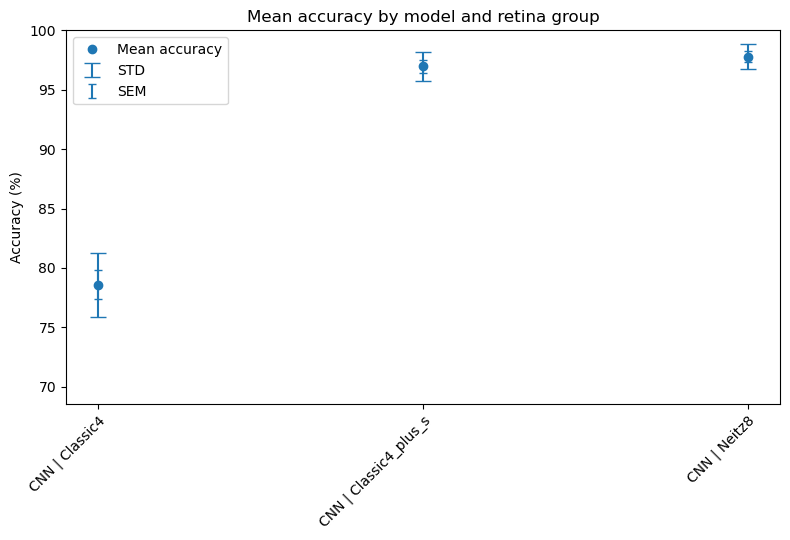

Saved accuracy plot: cnn_compare_v3_20260402_test1/evaluation_outputs/accuracy_dotplot_std_sem.png


,model,group,n_runs,accuracy_mean_percent,accuracy_std_percent,accuracy_sem_percent
0,CNN,Classic4,5,78.586957,2.712556,1.213092
1,CNN,Classic4_plus_s,5,96.956522,1.244606,0.556605
2,CNN,Neitz8,5,97.789855,1.074811,0.480670


In [11]:
# Cell 10 — Build, display, and save the accuracy summary figures  # Plot case-level mean accuracy as dots with STD and SEM error bars.
if "ACCURACY_SUMMARY_DF" not in globals() or len(ACCURACY_SUMMARY_DF) == 0:  # Stop when the case-level accuracy summary is missing.
    raise RuntimeError("Please run Cell 7 before building the accuracy figures.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
accuracy_plot_path = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME / "accuracy_dotplot_std_sem.png"  # Build the main shared accuracy-dot-plot output path.
plot_df = ACCURACY_SUMMARY_DF.copy().sort_values(["model", "group"], kind="mergesort").reset_index(drop=True)  # Build one stable plotting dataframe ordered by model and group.
plot_df["case_label"] = plot_df["model"].astype(str) + " | " + plot_df["group"].astype(str)  # Build one readable x-axis label per model-group case.
x_positions = np.arange(len(plot_df), dtype=float)  # Create one numeric x position per plotted case.
# ---  # Separate the code into small readable sections.
fig, ax = plt.subplots(figsize=(max(8.0, 1.25 * len(plot_df)), 5.5))  # Create one figure that expands horizontally as more cases are selected.
ax.plot(x_positions, plot_df["accuracy_mean_percent"].to_numpy(dtype=float), "o", label="Mean accuracy")  # Plot one circle marker at the mean accuracy for each case.
if SHOW_STD_ERROR_BARS:  # Add the requested standard-deviation error bars when enabled.
    ax.errorbar(x_positions, plot_df["accuracy_mean_percent"].to_numpy(dtype=float), yerr=plot_df["accuracy_std_percent"].to_numpy(dtype=float), fmt="none", capsize=6, label="STD")  # Draw the outer standard-deviation error bars around each mean dot.
if SHOW_SEM_ERROR_BARS:  # Add the requested standard-error error bars when enabled.
    ax.errorbar(x_positions, plot_df["accuracy_mean_percent"].to_numpy(dtype=float), yerr=plot_df["accuracy_sem_percent"].to_numpy(dtype=float), fmt="none", capsize=3, label="SEM")  # Draw the inner standard-error error bars around each mean dot.
ax.set_xticks(x_positions)  # Put one x tick at each plotted case location.
ax.set_xticklabels(plot_df["case_label"].tolist(), rotation=45, ha="right", rotation_mode="anchor")  # Show the readable case labels under the x ticks.
ax.set_ylabel("Accuracy (%)")  # Label the y axis in percent units.
ax.set_title("Mean accuracy by model and retina group")  # Add a descriptive plot title.
ax.set_ylim(bottom=max(0.0, float(np.nanmin(plot_df["accuracy_mean_percent"].to_numpy(dtype=float)) - 10.0)), top=min(100.0, float(np.nanmax(plot_df["accuracy_mean_percent"].to_numpy(dtype=float)) + 10.0)))  # Keep the y-axis limits focused on the observed accuracy range while staying inside 0 to 100.
ax.legend()  # Show the legend that distinguishes the mean dots, STD bars, and SEM bars.
fig.tight_layout()  # Tighten the layout so the rotated x labels fit cleanly.
fig.savefig(accuracy_plot_path, dpi=200, bbox_inches="tight")  # Save the main shared accuracy-dot plot to disk.
plt.show()  # Display the finished accuracy-dot plot inline.
plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
# ---  # Separate the code into small readable sections.
print("Saved accuracy plot:", accuracy_plot_path)  # Show where the main shared accuracy-dot plot was saved.
display(plot_df[["model", "group", "n_runs", "accuracy_mean_percent", "accuracy_std_percent", "accuracy_sem_percent"]])  # Display the plotted case-level accuracy values for quick inspection.

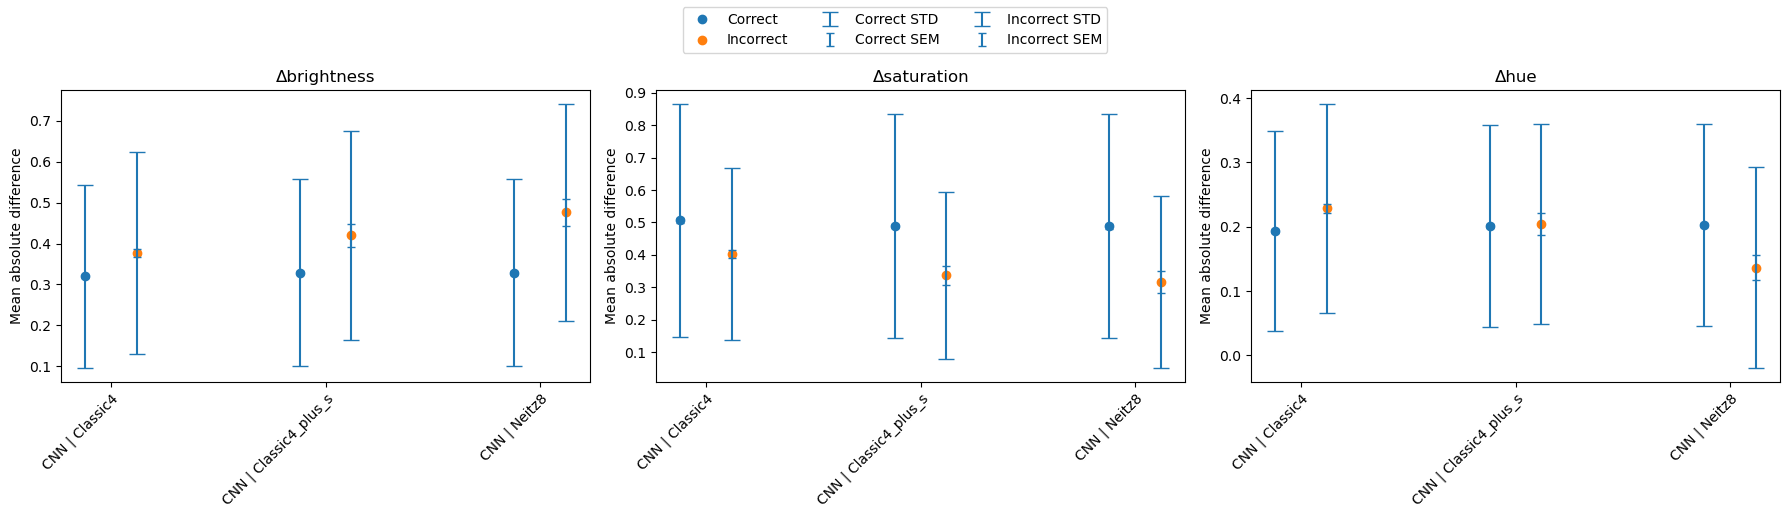

Saved contrast long table: cnn_compare_v3_20260402_test1/evaluation_outputs/contrast_analysis/contrast_distribution_long.csv
Saved contrast summary table: cnn_compare_v3_20260402_test1/evaluation_outputs/contrast_analysis/contrast_summary.csv
Saved contrast summary plot: cnn_compare_v3_20260402_test1/evaluation_outputs/contrast_analysis/contrast_summary_dotplot_std_sem.png
Saved contrast diagnostic table: cnn_compare_v3_20260402_test1/evaluation_outputs/contrast_analysis/contrast_brightness_hue_diagnostic.csv


,model,group,metric_name,outcome,n_rows,metric_mean,metric_median,metric_std,metric_sem
0,CNN,Classic4,delta_brightness,correct,2169,0.319569,0.290816,0.224732,0.004825
1,CNN,Classic4,delta_brightness,incorrect,591,0.377083,0.350000,0.247193,0.010168
2,CNN,Classic4,delta_hue,correct,2169,0.193484,0.166667,0.154989,0.003328
3,CNN,Classic4,delta_hue,incorrect,591,0.228708,0.166667,0.162679,0.006692
4,CNN,Classic4,delta_saturation,correct,2169,0.506017,0.500000,0.360491,0.007740
5,CNN,Classic4,delta_saturation,incorrect,591,0.402707,0.500000,0.266349,0.010956
6,CNN,Classic4_plus_s,delta_brightness,correct,2676,0.329105,0.300000,0.229583,0.004438
7,CNN,Classic4_plus_s,delta_brightness,incorrect,84,0.420445,0.375000,0.255237,0.027849
8,CNN,Classic4_plus_s,delta_hue,correct,2676,0.200922,0.166667,0.157372,0.003042
9,CNN,Classic4_plus_s,delta_hue,incorrect,84,0.204365,0.166667,0.155985,0.017019


In [13]:
# Cell 11 — Build, display, and save the contrast-analysis outputs  # Compare delta brightness, saturation, and hue for correct versus incorrect stimuli in each case.
if not INCLUDE_CONTRAST_ANALYSIS:  # Stop early when contrast analysis is disabled at the top of the notebook.
    print("Contrast analysis is disabled by the INCLUDE_CONTRAST_ANALYSIS setting in Cell 1.")  # Explain why this cell is not doing any work.
elif "RUN_PREDICTIONS_LONG_DF" not in globals() or len(RUN_PREDICTIONS_LONG_DF) == 0:  # Stop when the reconstructed run-prediction table is missing.
    raise RuntimeError("Please run Cell 6 before building the contrast-analysis outputs.")  # Explain which earlier step is required first.
else:  # Continue into the contrast-analysis workflow when the required inputs are available.
    contrast_output_dir = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME / "contrast_analysis"  # Build the shared contrast-analysis output folder path.
    contrast_long_df = RUN_PREDICTIONS_LONG_DF[["model", "group", "run_key", "stim_ID", "is_correct", "delta_brightness", "delta_saturation", "delta_hue"]].copy()  # Keep only the columns needed for the contrast analyses.
    contrast_long_df["outcome"] = np.where(contrast_long_df["is_correct"].astype(bool), "correct", "incorrect")  # Add one readable correct-versus-incorrect outcome column.
    stacked_parts = []  # Collect one long-format metric table per contrast metric.
    for metric_name in ["delta_brightness", "delta_saturation", "delta_hue"]:  # Stack the three contrast metrics into one long-format table.
        metric_df = contrast_long_df[["model", "group", "run_key", "stim_ID", "outcome", metric_name]].copy()  # Keep the current metric together with the core identifiers.
        metric_df = metric_df.rename(columns={metric_name: "metric_value"})  # Rename the current metric column to one shared long-format value column.
        metric_df["metric_name"] = str(metric_name)  # Record which contrast metric each long-format row belongs to.
        stacked_parts.append(metric_df)  # Save the current long-format metric table for later concatenation.
    CONTRAST_DISTRIBUTION_LONG_DF = pd.concat(stacked_parts, ignore_index=True) if len(stacked_parts) > 0 else pd.DataFrame()  # Combine the metric-specific long tables into one stacked long-format contrast table.
    CONTRAST_DISTRIBUTION_LONG_DF["metric_value"] = pd.to_numeric(CONTRAST_DISTRIBUTION_LONG_DF["metric_value"], errors="coerce")  # Convert the stacked metric values to numeric form.
    CONTRAST_DISTRIBUTION_LONG_DF = CONTRAST_DISTRIBUTION_LONG_DF.loc[~CONTRAST_DISTRIBUTION_LONG_DF["metric_value"].isna()].copy()  # Drop contrast rows that still lack a numeric value.
    contrast_summary_rows = []  # Collect one short summary row per case, metric, and outcome.
    for (model_name, group_name, metric_name, outcome_name), summary_df in CONTRAST_DISTRIBUTION_LONG_DF.groupby(["model", "group", "metric_name", "outcome"], sort=True):  # Summarize one case-metric-outcome combination at a time.
        metric_series = pd.to_numeric(summary_df["metric_value"], errors="coerce").dropna()  # Read the current metric values as one clean numeric series.
        contrast_summary_rows.append({"model": str(model_name), "group": str(group_name), "metric_name": str(metric_name), "outcome": str(outcome_name), "n_rows": int(len(metric_series)), "metric_mean": float(metric_series.mean()) if len(metric_series) > 0 else np.nan, "metric_median": float(metric_series.median()) if len(metric_series) > 0 else np.nan, "metric_std": float(metric_series.std(ddof=1)) if len(metric_series) > 1 else 0.0, "metric_sem": sem_from_series(metric_series)})  # Save the short summary values for the current case-metric-outcome combination.
    CONTRAST_SUMMARY_DF = pd.DataFrame(contrast_summary_rows).sort_values(["model", "group", "metric_name", "outcome"], kind="mergesort").reset_index(drop=True) if len(contrast_summary_rows) > 0 else pd.DataFrame(columns=["model", "group", "metric_name", "outcome", "n_rows", "metric_mean", "metric_median", "metric_std", "metric_sem"])  # Combine the short contrast-summary rows into one stable table.
    contrast_long_path = contrast_output_dir / "contrast_distribution_long.csv"  # Build the stacked long-format contrast-table CSV path.
    contrast_summary_path = contrast_output_dir / "contrast_summary.csv"  # Build the short contrast-summary CSV path.
    CONTRAST_DISTRIBUTION_LONG_DF.to_csv(contrast_long_path, index=False)  # Save the stacked long-format contrast table to disk.
    CONTRAST_SUMMARY_DF.to_csv(contrast_summary_path, index=False)  # Save the short contrast-summary table to disk.
    for (model_name, group_name), case_df in CONTRAST_DISTRIBUTION_LONG_DF.groupby(["model", "group"], sort=True):  # Build one matched three-panel distribution figure per case.
        fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), sharex=False)  # Create one row of three panels for brightness, saturation, and hue.
        for axis_obj, metric_name in zip(axes, ["delta_brightness", "delta_saturation", "delta_hue"]):  # Draw one distribution panel for each contrast metric.
            metric_case_df = case_df.loc[case_df["metric_name"].astype(str) == str(metric_name)].copy()  # Keep only the current metric rows for the current case.
            correct_values = pd.to_numeric(metric_case_df.loc[metric_case_df["outcome"].astype(str) == "correct", "metric_value"], errors="coerce").dropna().to_numpy(dtype=float)  # Read the correct-stimulus values for the current metric.
            incorrect_values = pd.to_numeric(metric_case_df.loc[metric_case_df["outcome"].astype(str) == "incorrect", "metric_value"], errors="coerce").dropna().to_numpy(dtype=float)  # Read the incorrect-stimulus values for the current metric.
            axis_obj.boxplot([correct_values, incorrect_values], tick_labels=["Correct", "Incorrect"])  # Draw a simple boxplot comparison for correct versus incorrect stimuli.
            if len(correct_values) > 0:  # Overlay jittered point values when correct-stimulus data exist.
                axis_obj.plot(np.random.normal(1.0, 0.03, size=len(correct_values)), correct_values, "o", alpha=0.25, markersize=3)  # Add lightly jittered correct-stimulus points over the boxplot.
            if len(incorrect_values) > 0:  # Overlay jittered point values when incorrect-stimulus data exist.
                axis_obj.plot(np.random.normal(2.0, 0.03, size=len(incorrect_values)), incorrect_values, "o", alpha=0.25, markersize=3)  # Add lightly jittered incorrect-stimulus points over the boxplot.
            axis_obj.set_title(metric_name.replace("delta_", "Δ").replace("_", " "))  # Add a readable metric title above the current panel.
            axis_obj.set_ylabel("Absolute difference")  # Label the y axis as an absolute object-background difference.
        fig.suptitle(f"{model_name} | {group_name} | Correct vs incorrect stimulus differences")  # Add a shared case-level title above the three-panel figure.
        fig.tight_layout()  # Tighten the layout so the panel labels and title fit cleanly.
        figure_path = contrast_output_dir / f"contrast_distribution_{sanitize_name(model_name)}_{sanitize_name(group_name)}.png"  # Build the saved three-panel distribution-figure path for the current case.
        fig.savefig(figure_path, dpi=200, bbox_inches="tight")  # Save the finished three-panel distribution figure to disk.
        plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
    summary_plot_path = contrast_output_dir / "contrast_summary_dotplot_std_sem.png"  # Build the shared summary dot-plot output path for the contrast analysis.
    fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.2), sharey=False)  # Create one row of three summary panels, one per contrast metric.
    ordered_cases = CONTRAST_SUMMARY_DF[["model", "group"]].drop_duplicates().sort_values(["model", "group"], kind="mergesort").reset_index(drop=True)  # Build the stable ordered case list used across all summary panels.
    ordered_cases["case_label"] = ordered_cases["model"].astype(str) + " | " + ordered_cases["group"].astype(str)  # Build the readable case labels used on the x axis.
    for axis_obj, metric_name in zip(axes, ["delta_brightness", "delta_saturation", "delta_hue"]):  # Draw one summary panel for each contrast metric.
        metric_summary_df = CONTRAST_SUMMARY_DF.loc[CONTRAST_SUMMARY_DF["metric_name"].astype(str) == str(metric_name)].copy()  # Keep only the current metric rows for the summary panel.
        for offset_value, outcome_name in [(-0.12, "correct"), (0.12, "incorrect")]:  # Plot correct and incorrect outcomes side by side inside the same panel.
            outcome_df = ordered_cases.merge(metric_summary_df.loc[metric_summary_df["outcome"].astype(str) == str(outcome_name)], on=["model", "group"], how="left")  # Align the current metric-outcome rows to the stable ordered case list.
            x_values = np.arange(len(outcome_df), dtype=float) + float(offset_value)  # Offset the x positions so correct and incorrect dots do not overlap.
            axis_obj.plot(x_values, outcome_df["metric_mean"].to_numpy(dtype=float), "o", label=outcome_name.title())  # Plot one circle marker at the mean metric value for each case and outcome.
            if SHOW_STD_ERROR_BARS:  # Add standard-deviation error bars around the mean dots when requested.
                axis_obj.errorbar(x_values, outcome_df["metric_mean"].to_numpy(dtype=float), yerr=outcome_df["metric_std"].to_numpy(dtype=float), fmt="none", capsize=6, label=f"{outcome_name.title()} STD")  # Draw the standard-deviation error bars for the current outcome.
            if SHOW_SEM_ERROR_BARS:  # Add standard-error error bars around the mean dots when requested.
                axis_obj.errorbar(x_values, outcome_df["metric_mean"].to_numpy(dtype=float), yerr=outcome_df["metric_sem"].to_numpy(dtype=float), fmt="none", capsize=3, label=f"{outcome_name.title()} SEM")  # Draw the standard-error error bars for the current outcome.
        axis_obj.set_xticks(np.arange(len(ordered_cases), dtype=float))  # Put one x tick at each ordered case location.
        axis_obj.set_xticklabels(ordered_cases["case_label"].tolist(), rotation=45, ha="right", rotation_mode="anchor")  # Show the readable ordered case labels under the x ticks.
        axis_obj.set_title(metric_name.replace("delta_", "Δ").replace("_", " "))  # Add a readable metric title above the current summary panel.
        axis_obj.set_ylabel("Mean absolute difference")  # Label the y axis as a mean absolute object-background difference.
    handles, labels = axes[0].get_legend_handles_labels()  # Read the legend entries from the first summary panel.
    unique_legend = dict(zip(labels, handles))  # Keep one handle per legend label so the shared legend does not repeat entries.
    fig.legend(unique_legend.values(), unique_legend.keys(), loc="upper center", ncol=3)  # Add one shared legend above the summary panels.
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.90])  # Tighten the layout while leaving room for the shared legend.
    fig.savefig(summary_plot_path, dpi=200, bbox_inches="tight")  # Save the finished contrast-summary dot plot to disk.
    plt.show()  # Display the finished contrast-summary dot plot inline.
    plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
    # ---  # Separate the code into small readable sections.
    diagnostic_source_df = RUN_PREDICTIONS_LONG_DF[["model", "group", "run_key", "stim_ID", "is_correct", "delta_brightness", "delta_hue"]].copy()  # Keep the brightness and hue columns needed for the diagnostic performance plot.
    diagnostic_source_df["delta_brightness"] = pd.to_numeric(diagnostic_source_df["delta_brightness"], errors="coerce")  # Convert brightness differences to numeric values for safe binning.
    diagnostic_source_df["delta_hue"] = pd.to_numeric(diagnostic_source_df["delta_hue"], errors="coerce")  # Convert hue differences to numeric values for safe binning.
    diagnostic_source_df = diagnostic_source_df.loc[~diagnostic_source_df["delta_brightness"].isna() & ~diagnostic_source_df["delta_hue"].isna()].copy()  # Keep only rows that have both brightness and hue differences for the diagnostic plot.
    diagnostic_rows = []  # Collect one summary row per case, brightness bin, and hue level.
    for (model_name, group_name), case_df in diagnostic_source_df.groupby(["model", "group"], sort=True):  # Build one diagnostic summary per selected case.
        hue_cutoff = float(case_df["delta_hue"].median()) if len(case_df) > 0 else np.nan  # Use the case-level median hue difference to separate low-hue and high-hue stimuli.
        case_df = case_df.copy()  # Work from a local case copy before adding hue and bin columns.
        case_df["hue_level"] = np.where(case_df["delta_hue"].astype(float) <= hue_cutoff, "low_hue", "high_hue")  # Split the current case into low-hue and high-hue subsets using the case-level median hue difference.
        try:  # Try to create quantile-based brightness bins first.
            brightness_bins = pd.qcut(case_df["delta_brightness"].astype(float), q=min(5, max(2, case_df["delta_brightness"].nunique())), duplicates="drop")  # Build up to five brightness bins with roughly balanced row counts.
        except Exception:  # Fall back to simple equal-width bins when quantile binning fails.
            brightness_bins = pd.cut(case_df["delta_brightness"].astype(float), bins=min(5, max(2, case_df["delta_brightness"].nunique())))  # Build up to five equal-width brightness bins as a fallback.
        case_df["brightness_bin"] = brightness_bins.astype(str)  # Save the brightness-bin labels as plain text for grouping and plotting.
        for (brightness_bin_value, hue_level_value), bin_df in case_df.groupby(["brightness_bin", "hue_level"], sort=False):  # Summarize one brightness-bin and hue-level subset at a time.
            valid_brightness = pd.to_numeric(bin_df["delta_brightness"], errors="coerce").dropna()  # Read the valid brightness values within the current subset.
            diagnostic_rows.append({"model": str(model_name), "group": str(group_name), "brightness_bin": str(brightness_bin_value), "hue_level": str(hue_level_value), "brightness_bin_center": float(valid_brightness.mean()) if len(valid_brightness) > 0 else np.nan, "n_rows": int(len(bin_df)), "accuracy_mean": float(pd.to_numeric(bin_df["is_correct"], errors="coerce").mean()) if len(bin_df) > 0 else np.nan, "error_rate": float(1.0 - pd.to_numeric(bin_df["is_correct"], errors="coerce").mean()) if len(bin_df) > 0 else np.nan})  # Save one diagnostic row for the current brightness-bin and hue-level subset.
    CONTRAST_DIAGNOSTIC_DF = pd.DataFrame(diagnostic_rows).sort_values(["model", "group", "hue_level", "brightness_bin_center"], kind="mergesort").reset_index(drop=True) if len(diagnostic_rows) > 0 else pd.DataFrame(columns=["model", "group", "brightness_bin", "hue_level", "brightness_bin_center", "n_rows", "accuracy_mean", "error_rate"])  # Combine the diagnostic rows into one stable summary table.
    diagnostic_csv_path = contrast_output_dir / "contrast_brightness_hue_diagnostic.csv"  # Build the saved diagnostic summary CSV path.
    CONTRAST_DIAGNOSTIC_DF.to_csv(diagnostic_csv_path, index=False)  # Save the brightness-by-hue diagnostic summary table to disk.
    for (model_name, group_name), case_diag_df in CONTRAST_DIAGNOSTIC_DF.groupby(["model", "group"], sort=True):  # Build one diagnostic line plot per selected case.
        fig, ax = plt.subplots(figsize=(7.5, 4.8))  # Create one figure for the current case diagnostic plot.
        for hue_level_value in ["low_hue", "high_hue"]:  # Plot the low-hue and high-hue subsets separately on the same axes.
            hue_df = case_diag_df.loc[case_diag_df["hue_level"].astype(str) == str(hue_level_value)].copy().sort_values("brightness_bin_center", kind="mergesort")  # Keep the current hue subset in stable brightness-bin order.
            if len(hue_df) == 0:  # Skip hue subsets that have no rows for the current case.
                continue  # Move on to the next hue subset.
            ax.plot(hue_df["brightness_bin_center"].to_numpy(dtype=float), hue_df["error_rate"].to_numpy(dtype=float), "o-", label=hue_level_value.replace("_", " ").title())  # Plot error rate against brightness-bin center for the current hue subset.
        ax.set_xlabel("Binned |Δ brightness|")  # Label the x axis as the binned absolute brightness difference.
        ax.set_ylabel("Error rate")  # Label the y axis as the model error rate within each brightness bin.
        ax.set_title(f"{model_name} | {group_name} | Error rate vs brightness by hue level")  # Add a descriptive title above the diagnostic plot.
        ax.legend()  # Show the legend that distinguishes low-hue and high-hue subsets.
        fig.tight_layout()  # Tighten the layout so labels and the legend fit cleanly.
        diagnostic_plot_path = contrast_output_dir / f"contrast_error_rate_vs_brightness_{sanitize_name(model_name)}_{sanitize_name(group_name)}.png"  # Build the saved diagnostic figure path for the current case.
        fig.savefig(diagnostic_plot_path, dpi=200, bbox_inches="tight")  # Save the finished diagnostic figure to disk.
        plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
    print("Saved contrast long table:", contrast_long_path)  # Show where the stacked long-format contrast table was saved.
    print("Saved contrast summary table:", contrast_summary_path)  # Show where the short contrast-summary table was saved.
    print("Saved contrast summary plot:", summary_plot_path)  # Show where the contrast-summary dot plot was saved.
    print("Saved contrast diagnostic table:", diagnostic_csv_path)  # Show where the brightness-by-hue diagnostic table was saved.
    display(CONTRAST_SUMMARY_DF)  # Display the short contrast-summary table for quick inspection.

In [14]:
# Cell 12 — Final output summary and saved-file manifest  # Collect the key saved outputs, save a manifest table, and display the final notebook summaries.
if "ACTIVE_EVAL_SUMMARY_LONG_DF" not in globals() or len(ACTIVE_EVAL_SUMMARY_LONG_DF) == 0:  # Stop when the aggregated long confusion summary is missing.
    raise RuntimeError("Please run Cell 7 before building the final output manifest.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
summaries_dir = NOTEBOOK_OUTPUT_DIR / "summaries"  # Build the shared summaries folder path.
eval_output_dir = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME  # Build the shared evaluation-output folder path.
difference_output_dir = eval_output_dir / "difference_matrices"  # Build the shared difference-matrix output folder path.
contrast_output_dir = eval_output_dir / "contrast_analysis"  # Build the shared contrast-analysis output folder path.
manifest_rows = []  # Collect one manifest row per saved file.
for file_path in sorted(NOTEBOOK_OUTPUT_DIR.rglob("*")):  # Walk through every saved file inside the notebook-output folder.
    if file_path.is_dir():  # Skip folders and keep only real files in the manifest.
        continue  # Move on to the next saved path.
    manifest_rows.append({"category": str(file_path.parent.relative_to(NOTEBOOK_OUTPUT_DIR)), "filename": str(file_path.name), "path": str(file_path), "exists": bool(file_path.exists()), "size_bytes": int(file_path.stat().st_size) if file_path.exists() else np.nan})  # Save one readable manifest row for the current file.
OUTPUT_MANIFEST_DF = pd.DataFrame(manifest_rows).sort_values(["category", "filename"], kind="mergesort").reset_index(drop=True) if len(manifest_rows) > 0 else pd.DataFrame(columns=["category", "filename", "path", "exists", "size_bytes"])  # Combine the saved file rows into one stable manifest table.
output_manifest_path = NOTEBOOK_OUTPUT_DIR / "output_manifest.csv"  # Build the saved output-manifest CSV path.
OUTPUT_MANIFEST_DF.to_csv(output_manifest_path, index=False)  # Save the output-manifest table to disk.
# ---  # Separate the code into small readable sections.
selected_case_count = int(ACTIVE_EVAL_SUMMARY_LONG_DF[["model", "group"]].drop_duplicates().shape[0])  # Count how many model-group cases were aggregated in this notebook run.
difference_pair_count = int(DIFFERENCE_MATRICES_SUMMARY_DF.shape[0]) if "DIFFERENCE_MATRICES_SUMMARY_DF" in globals() else 0  # Count how many difference-matrix group pairs were built in this notebook run.
contrast_case_count = int(CONTRAST_SUMMARY_DF[["model", "group"]].drop_duplicates().shape[0]) if "CONTRAST_SUMMARY_DF" in globals() else 0  # Count how many cases contributed contrast-analysis outputs in this notebook run.
selected_eval_dir_count = int(SELECTED_RUNS_DF["run_dir_name"].astype(str).nunique()) if "SELECTED_RUNS_DF" in globals() and len(SELECTED_RUNS_DF) > 0 else 0  # Count how many distinct CNN evaluation-output folders contributed selected runs.
final_summary_rows = [{"notebook_name": "CNN_compare_v3.ipynb", "gray_handling_mode": str(EVAL_MODE_SUFFIX), "aggregation_method": str(AGGREGATION_METHOD), "label_source": str(LABEL_SOURCE_SUFFIX), "eval_choice": str(EVAL_CHOICE), "n_selected_runs": int(SELECTED_RUNS_DF.shape[0]) if "SELECTED_RUNS_DF" in globals() else 0, "n_selected_eval_dirs": selected_eval_dir_count, "n_selected_cases": selected_case_count, "n_difference_pairs": difference_pair_count, "n_contrast_cases": contrast_case_count, "output_dir": str(NOTEBOOK_OUTPUT_DIR)}]  # Build the final one-row notebook summary table.
FINAL_NOTEBOOK_SUMMARY_DF = pd.DataFrame(final_summary_rows)  # Convert the final summary row into a dataframe for saving and display.
final_summary_path = NOTEBOOK_OUTPUT_DIR / "final_notebook_summary.csv"  # Build the saved final notebook-summary CSV path.
FINAL_NOTEBOOK_SUMMARY_DF.to_csv(final_summary_path, index=False)  # Save the final notebook-summary table to disk.
# ---  # Separate the code into small readable sections.
print("Saved output manifest:", output_manifest_path)  # Show where the output-manifest table was saved.
print("Saved final notebook summary:", final_summary_path)  # Show where the final one-row notebook summary was saved.
display(FINAL_NOTEBOOK_SUMMARY_DF)  # Display the final notebook-summary table for quick inspection.
display(OUTPUT_MANIFEST_DF)  # Display the saved-file manifest table for quick inspection.


Saved output manifest: cnn_compare_v3_20260402_test1/output_manifest.csv
Saved final notebook summary: cnn_compare_v3_20260402_test1/final_notebook_summary.csv


,notebook_name,gray_handling_mode,aggregation_method,label_source,eval_choice,n_selected_runs,n_selected_eval_dirs,n_selected_cases,n_difference_pairs,n_contrast_cases,output_dir
0,CNN_compare_v3.ipynb,gray_merged,mean_percent,auto_labels,test_best,15,2,3,3,3,cnn_compare_v3_20260402_test1


,category,filename,path,exists,size_bytes
0,evaluation_outputs,accuracy_dotplot_std_sem.png,cnn_compare_v3_20260402_test1/evaluation_outpu...,True,68545
1,evaluation_outputs,accuracy_summary.csv,cnn_compare_v3_20260402_test1/evaluation_outpu...,True,564
2,evaluation_outputs,auto_labels_cm_pct_CNN_Classic4_gray_merged_an...,cnn_compare_v3_20260402_test1/evaluation_outpu...,True,82513
3,evaluation_outputs,auto_labels_cm_pct_CNN_Classic4_gray_merged_bl...,cnn_compare_v3_20260402_test1/evaluation_outpu...,True,59536
4,evaluation_outputs,auto_labels_cm_pct_CNN_Classic4_plus_s_gray_me...,cnn_compare_v3_20260402_test1/evaluation_outpu...,True,78587
5,evaluation_outputs,auto_labels_cm_pct_CNN_Classic4_plus_s_gray_me...,cnn_compare_v3_20260402_test1/evaluation_outpu...,True,60562
6,evaluation_outputs,auto_labels_cm_pct_CNN_Neitz8_gray_merged_anno...,cnn_compare_v3_20260402_test1/evaluation_outpu...,True,77172
7,evaluation_outputs,auto_labels_cm_pct_CNN_Neitz8_gray_merged_blan...,cnn_compare_v3_20260402_test1/evaluation_outpu...,True,59196
8,evaluation_outputs,confusion_matrix_manifest.csv,cnn_compare_v3_20260402_test1/evaluation_outpu...,True,722
9,evaluation_outputs/contrast_analysis,contrast_brightness_hue_diagnostic.csv,cnn_compare_v3_20260402_test1/evaluation_outpu...,True,3015
